In [1]:
# final worksflow of the 1D-code


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

from scipy.ndimage import gaussian_filter1d

In [3]:
N_BINS = 40
SIGMA = 1.0
EPS = 1e-10


In [4]:
def get_input_data(trajectory_results_path, layer_name):
    '''
    Expects trajectory_results_path to unpickle to a list of dicts, each with a
    'pred_position' array and a layer_name array (as in trajectory_results.pkl).
    Trajectories may have different lengths, so positions/activations are returned
    as lists (one entry per trajectory), not stacked arrays.
    Returns positions_list (each (T,)) and activations_list (each (T, n_neurons)).
    '''
    with open(trajectory_results_path, 'rb') as f:
        trajectory_results = pickle.load(f)

    positions_list = []
    activations_list = []
    for traj in trajectory_results:
        pos = np.asarray(traj['pred_position']).reshape(-1)
        act = np.asarray(traj[layer_name]).reshape(-1, np.asarray(traj[layer_name]).shape[-1])
        positions_list.append(pos)
        activations_list.append(act)

    return positions_list, activations_list

In [5]:
def get_track_bounds(positions_list):
    '''Fixed (min, max) computed once across every trajectory, shared by every map so bins line up.'''
    all_pos = np.concatenate(positions_list)
    return (float(all_pos.min()), float(all_pos.max()))

In [6]:
def bin_positions(
    positions,
    bins=N_BINS,
    bounds=None,
):
    """
    Assign every position sample to a spatial bin.

    Returns
    -------
    bin_indices : (T,)
    edges : (bins+1,)
    """

    edges = np.linspace(bounds[0], bounds[1], bins + 1)

    bin_indices = np.digitize(
        positions,
        edges,
        right=False,
    ) - 1

    bin_indices = np.clip(
        bin_indices,
        0,
        bins - 1,
    )

    return bin_indices, edges

In [7]:
def compute_occupancy_maps(
    bin_indices,
    bins=N_BINS,
):
    """
    Compute both occupancy maps.

    Parameters
    ----------
    bin_indices : ndarray
        Bin index for every position sample.

    Returns
    -------
    count_occupancy : ndarray
        Number of samples in each spatial bin.

    probability_occupancy : ndarray
        Occupancy normalized to sum to 1.
    """

    # Count occupancy
    count_occupancy = np.bincount(
        bin_indices,
        minlength=bins,
    ).astype(float)

    # Probability occupancy
    total_samples = np.sum(count_occupancy)

    if total_samples > 0:
        probability_occupancy = count_occupancy / total_samples
    else:
        probability_occupancy = np.zeros_like(count_occupancy)

    return count_occupancy, probability_occupancy

In [8]:
def compute_activity_maps(
    activity,
    bin_indices,
    bins=N_BINS,
):
    """
    Compute activity maps for ONE neuron.
    """

    amplitude = np.abs(activity)
    real = np.real(activity)

    amplitude_activity = np.zeros(bins)
    real_activity = np.zeros(bins)

    for b in range(bins):

        mask = (bin_indices == b)

        amplitude_activity[b] = amplitude[mask].sum()
        real_activity[b] = real[mask].sum()

    return amplitude_activity, real_activity

In [9]:
def compute_firing_rate_map(
    activity_map,
    occupancy_map,
    eps=EPS,
):
    """
    Compute firing-rate map by dividing activity by occupancy.

    Parameters
    ----------
    activity_map : ndarray
    occupancy_map : ndarray

    Returns
    -------
    firing_rate_map : ndarray
    """

    firing_rate = np.divide(
        activity_map,
        occupancy_map + eps,
    )

    # Explicitly set empty occupancy bins to zero
    firing_rate[occupancy_map == 0] = 0

    return firing_rate

In [10]:
def smooth_firing_rate_map(
    firing_rate_map,
    sigma=SIGMA,
):
    """
    Apply 1D Gaussian smoothing to a firing-rate map.

    Parameters
    ----------
    firing_rate_map : ndarray
        Unsmoothed firing-rate map.

    sigma : float
        Standard deviation of Gaussian kernel.

    Returns
    -------
    smoothed_rate : ndarray
    """

    smoothed_rate = gaussian_filter1d(
        firing_rate_map,
        sigma=sigma,
        mode="nearest",
    )

    return smoothed_rate

In [11]:
#select layer and load data

layer_name = "d3"

In [12]:

trajectory_results_path = "/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells/1D-place-grid-cells/data-trajectory_results.pkl"

positions_list, activations_list = get_input_data(
    trajectory_results_path,
    layer_name,
)

bounds = get_track_bounds(positions_list)

print("Number of trajectories:", len(positions_list))
print("Track bounds:", bounds)

Number of trajectories: 10
Track bounds: (0.05847848206758499, 0.9714955687522888)


In [13]:
trajectory = 0
neuron = 30

positions = positions_list[trajectory]
activity = activations_list[trajectory][:, neuron]

bin_indices, edges = bin_positions(
    positions,
    bins=N_BINS,
    bounds=bounds,
)

count_occ, prob_occ = compute_occupancy_maps(
    bin_indices,
    bins=N_BINS,
)

print("Count Occupancy")
print(count_occ)

print()

print("Probability Occupancy")
print(prob_occ)

print()

print("Sum of probabilities =", prob_occ.sum())

Count Occupancy
[13. 56. 38. 23. 15. 12. 26.  3. 11. 18.  8. 21. 29. 24.  6. 11. 11.  9.
 13. 15. 24. 28. 20. 11. 12. 12. 12. 10.  9.  5. 10. 17. 10. 18. 17. 28.
 31. 19. 11.  0.]

Probability Occupancy
[0.01951952 0.08408408 0.05705706 0.03453453 0.02252252 0.01801802
 0.03903904 0.0045045  0.01651652 0.02702703 0.01201201 0.03153153
 0.04354354 0.03603604 0.00900901 0.01651652 0.01651652 0.01351351
 0.01951952 0.02252252 0.03603604 0.04204204 0.03003003 0.01651652
 0.01801802 0.01801802 0.01801802 0.01501502 0.01351351 0.00750751
 0.01501502 0.02552553 0.01501502 0.02702703 0.02552553 0.04204204
 0.04654655 0.02852853 0.01651652 0.        ]

Sum of probabilities = 1.0


In [14]:
amplitude_activity, real_activity = compute_activity_maps(
    activity,
    bin_indices,
)

print("Amplitude Activity")
print(amplitude_activity)

print()

print("Real-Part Activity")
print(real_activity)

print()

print("Total Amplitude =", amplitude_activity.sum())
print("Total Real =", real_activity.sum())

Amplitude Activity
[20.13603592 95.06915283 56.5981369  16.059515   17.23641396 35.02766037
 87.80432892  5.92855358 40.10334778 13.73086452  2.29549265 11.43555927
 12.26758575  9.30919838  5.01569271  4.2228775   3.67937994  1.46782446
 24.92214012 24.8887558  31.38809967 43.58779144 22.92328262 16.66853333
 16.12023354  9.73134422  6.82922363 14.61545849  7.42548943 10.71565819
 21.95282555 32.32290649 13.38286209 10.01247883 31.46608925 32.18597794
 32.97434235 37.77967453  2.96880913  0.        ]

Real-Part Activity
[10.26010704 50.54636383 54.40000916 12.22010231  9.74733257 13.12745571
 54.87984467  5.92855358 31.91749191  6.85607052  0.67518359 10.63260269
  9.2276125   6.91873789  3.89850116  2.49336219  2.44906282  1.32728887
 24.89528084 13.57605934 24.700634   31.4557972  11.20659065  4.09502602
 10.29452324  4.74538946  2.33547854  2.7743082   3.48860693  0.33097476
 10.55549335 29.89897537  9.51112175  4.28067923  8.18302345 18.09871101
 21.93512917 32.61180115  0.       

In [15]:
amp_count_rate = compute_firing_rate_map(
    amplitude_activity,
    count_occ,
)

amp_prob_rate = compute_firing_rate_map(
    amplitude_activity,
    prob_occ,
)

real_count_rate = compute_firing_rate_map(
    real_activity,
    count_occ,
)

real_prob_rate = compute_firing_rate_map(
    real_activity,
    prob_occ,
)

print("Amplitude ÷ Count Occupancy")
print(amp_count_rate)

print("\nAmplitude ÷ Probability Occupancy")
print(amp_prob_rate)

print("\nReal ÷ Count Occupancy")
print(real_count_rate)

print("\nReal ÷ Probability Occupancy")
print(real_prob_rate)

Amplitude ÷ Count Occupancy
[1.54892584 1.69766344 1.48942466 0.69823978 1.14909426 2.9189717
 3.37708957 1.97618453 3.64575889 0.76282581 0.28693658 0.54455044
 0.4230202  0.38788327 0.83594879 0.38389795 0.33448909 0.16309161
 1.9170877  1.65925039 1.30783749 1.55670684 1.14616413 1.51532121
 1.34335279 0.81094535 0.56910197 1.46154585 0.82505438 2.14313164
 2.19528255 1.90134744 1.33828621 0.55624882 1.85094643 1.14949921
 1.06368846 1.98840392 0.26989174 0.        ]

Amplitude ÷ Probability Occupancy
[1031.58460411 1130.64385198  991.9568187   465.02769385  765.29677623
 1944.03513974 2249.14165038 1316.13886582 2428.07540533  508.04198554
  191.09976144  362.67059293  281.73145151  258.33025431  556.74188473
  255.67603633  222.76972957  108.61900917 1276.78040276 1105.06075254
  871.01976344 1036.76675114  763.34530881 1009.20392067  894.67295627
  540.08960138  379.02190952  973.38952885  549.48621343 1427.32565161
 1462.05817164 1266.29739063  891.29860933  370.46171528 1232.73

In [16]:
amp_count_rate_smoothed = smooth_firing_rate_map(amp_count_rate)

amp_prob_rate_smoothed = smooth_firing_rate_map(amp_prob_rate)

real_count_rate_smoothed = smooth_firing_rate_map(real_count_rate)

real_prob_rate_smoothed = smooth_firing_rate_map(real_prob_rate)

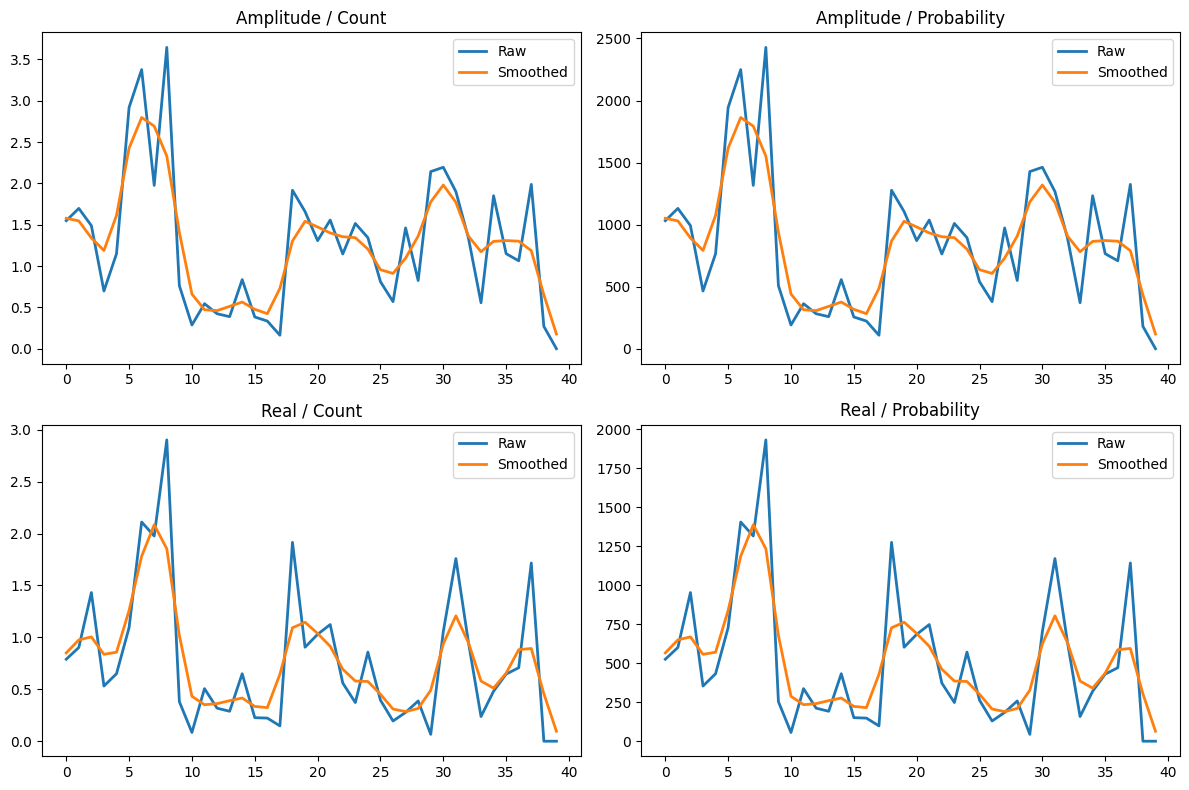

In [17]:
fig, ax = plt.subplots(2,2, figsize=(12,8))

maps = [
    ("Amplitude / Count", amp_count_rate, amp_count_rate_smoothed),
    ("Amplitude / Probability", amp_prob_rate, amp_prob_rate_smoothed),
    ("Real / Count", real_count_rate, real_count_rate_smoothed),
    ("Real / Probability", real_prob_rate, real_prob_rate_smoothed),
]

for axis, (title, raw, smooth) in zip(ax.ravel(), maps):

    axis.plot(raw, label="Raw", linewidth=2)

    axis.plot(smooth, label="Smoothed", linewidth=2)

    axis.set_title(title)

    axis.legend()

plt.tight_layout()
plt.show()

#process all the neurons in the selected traj

In [18]:
all_results = []

trajectory = 0

positions = positions_list[trajectory]

bin_indices, edges = bin_positions(
    positions,
    bins=N_BINS,
    bounds=bounds,
)

count_occ, prob_occ = compute_occupancy_maps(
    bin_indices,
    bins=N_BINS,
)

n_neurons = activations_list[trajectory].shape[1]

for neuron in range(n_neurons):

    activity = activations_list[trajectory][:, neuron]

    amp_activity, real_activity = compute_activity_maps(
        activity,
        bin_indices,
    )

    amp_count = compute_firing_rate_map(
        amp_activity,
        count_occ,
    )

    amp_prob = compute_firing_rate_map(
        amp_activity,
        prob_occ,
    )

    real_count = compute_firing_rate_map(
        real_activity,
        count_occ,
    )

    real_prob = compute_firing_rate_map(
        real_activity,
        prob_occ,
    )

    amp_count_s = smooth_firing_rate_map(amp_count)

    amp_prob_s = smooth_firing_rate_map(amp_prob)

    real_count_s = smooth_firing_rate_map(real_count)

    real_prob_s = smooth_firing_rate_map(real_prob)

    all_results.append({
        "neuron": neuron,

        "amplitude_activity": amp_activity,
        "real_activity": real_activity,

        "amp_count_rate": amp_count,
        "amp_prob_rate": amp_prob,

        "real_count_rate": real_count,
        "real_prob_rate": real_prob,

        "amp_count_smoothed": amp_count_s,
        "amp_prob_smoothed": amp_prob_s,

        "real_count_smoothed": real_count_s,
        "real_prob_smoothed": real_prob_s,
    })

print(f"Processed {len(all_results)} neurons.")


Processed 50 neurons.


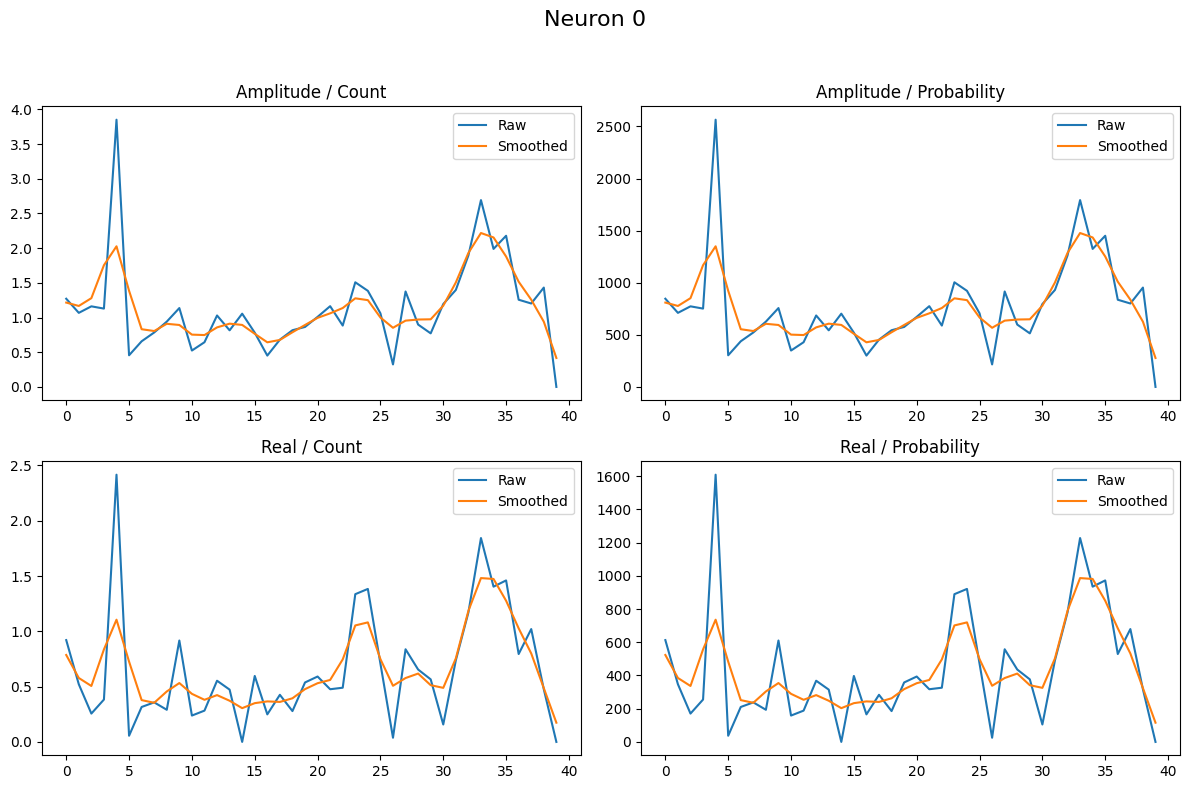

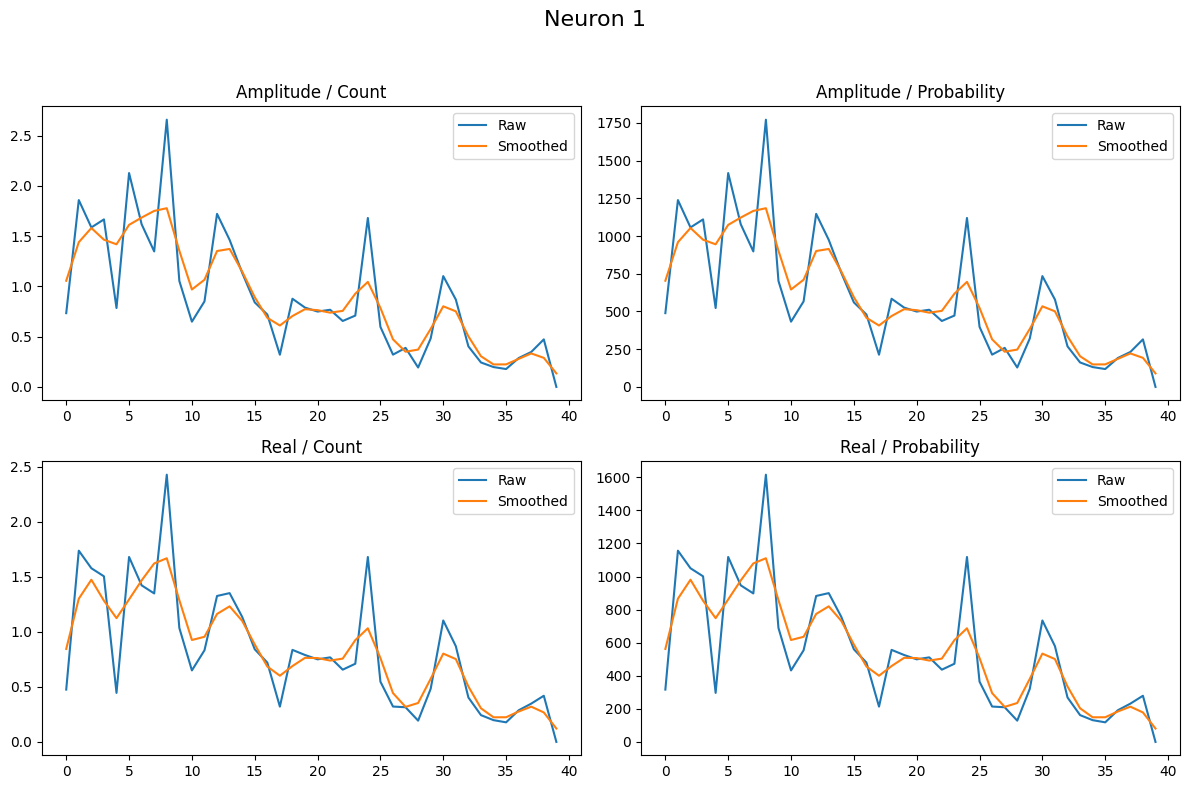

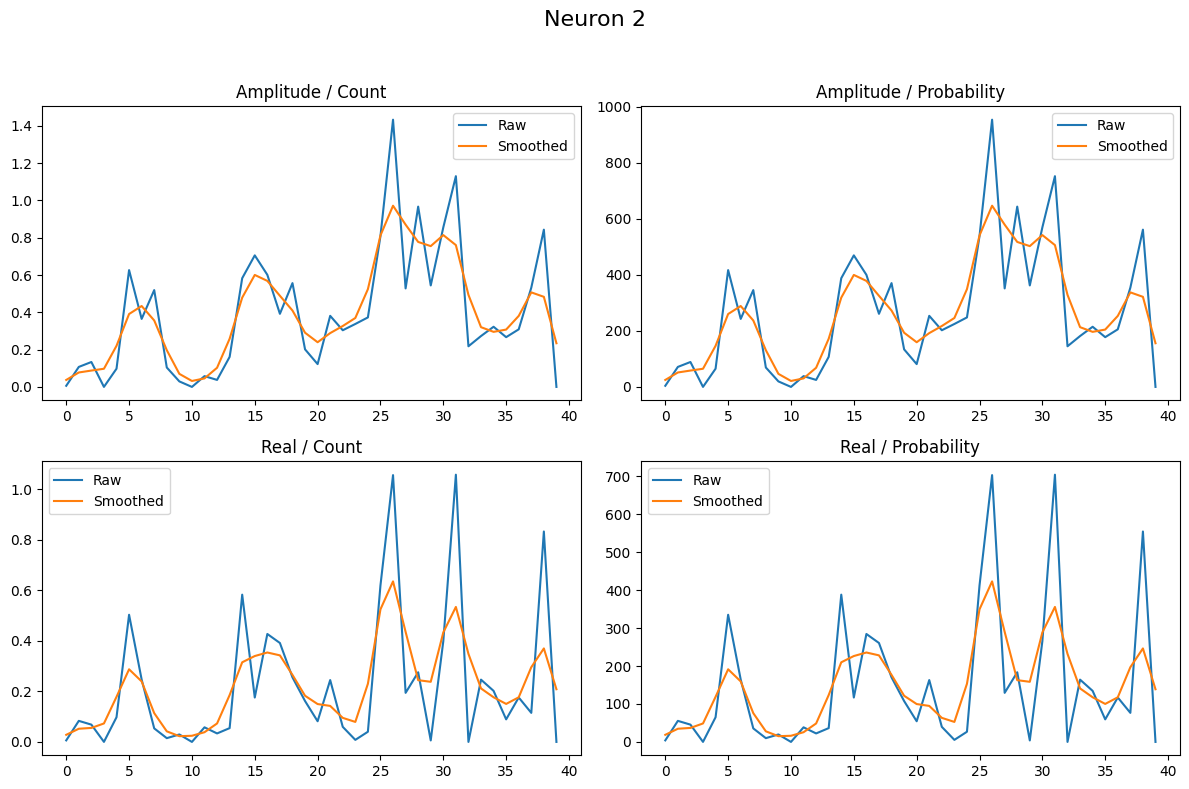

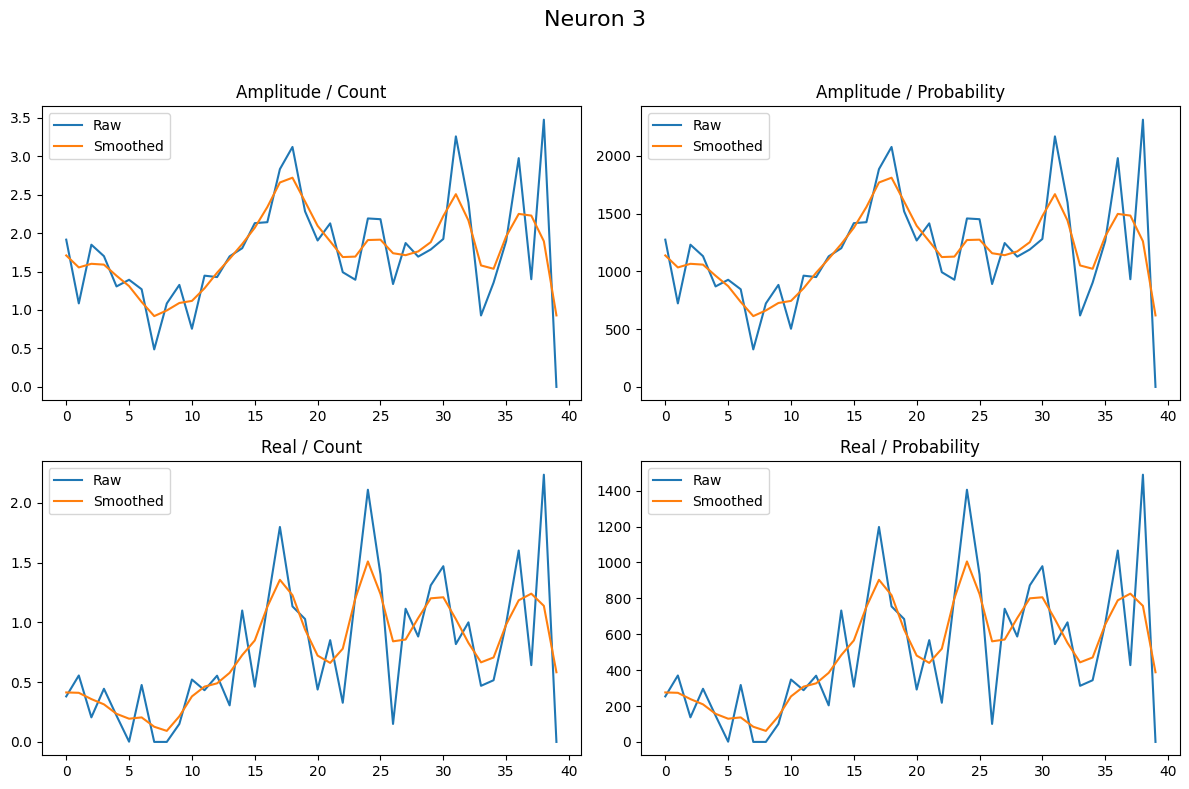

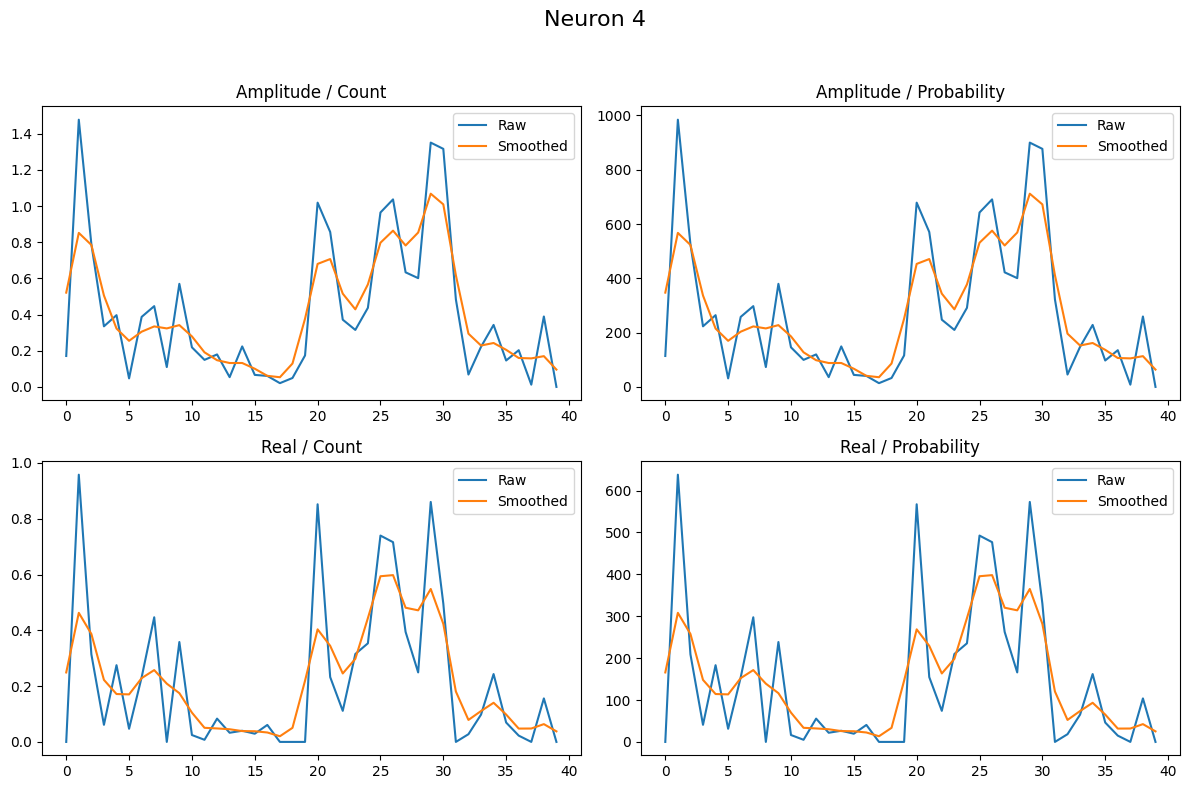

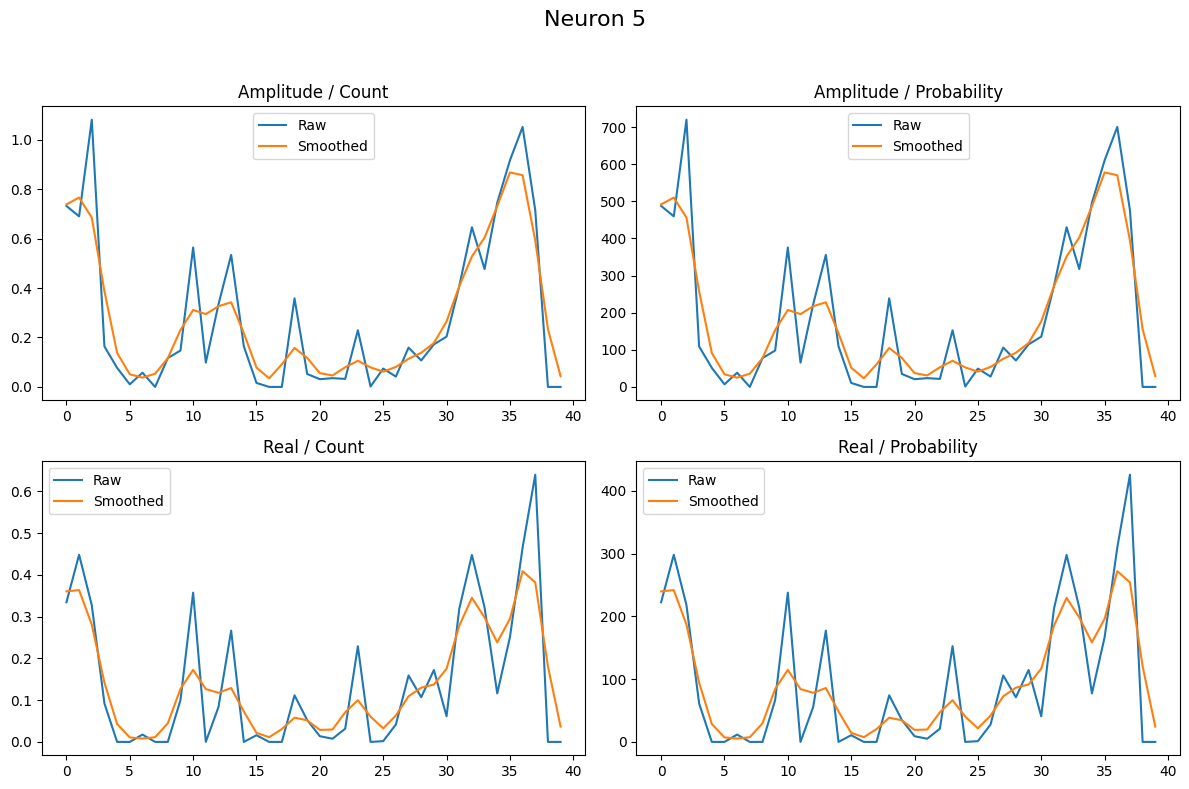

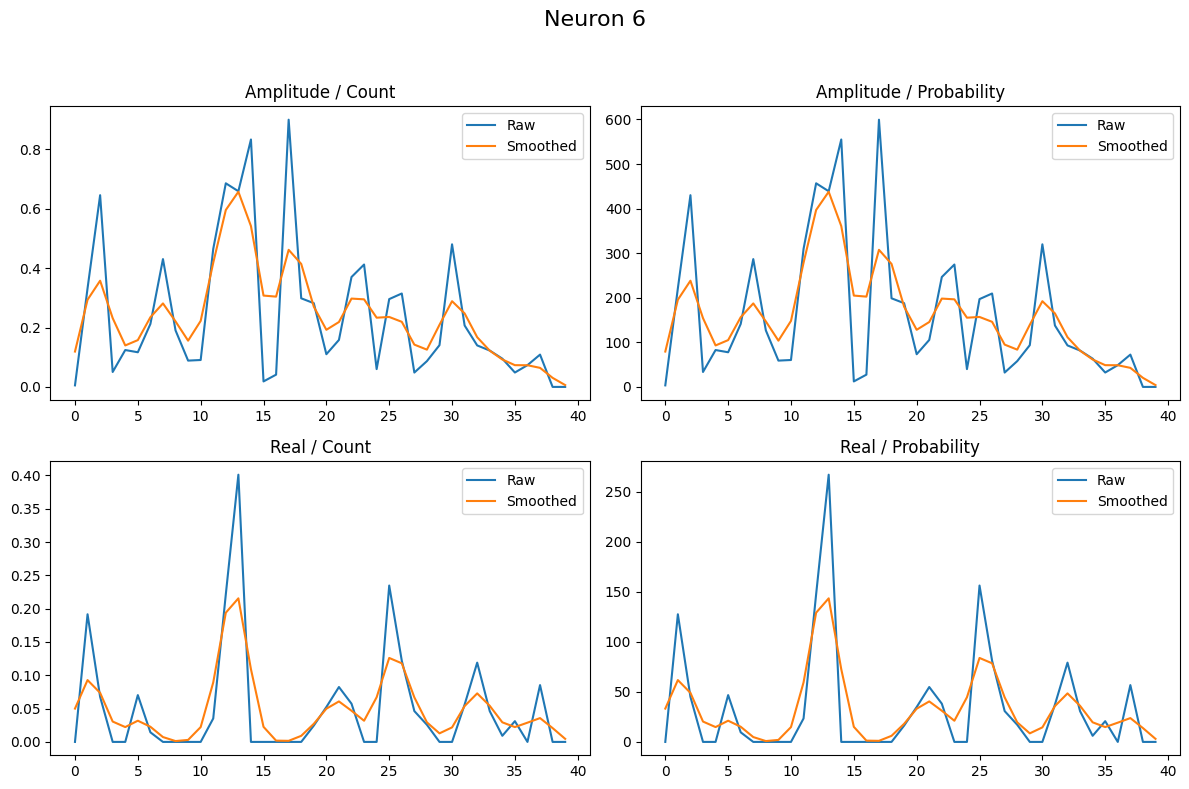

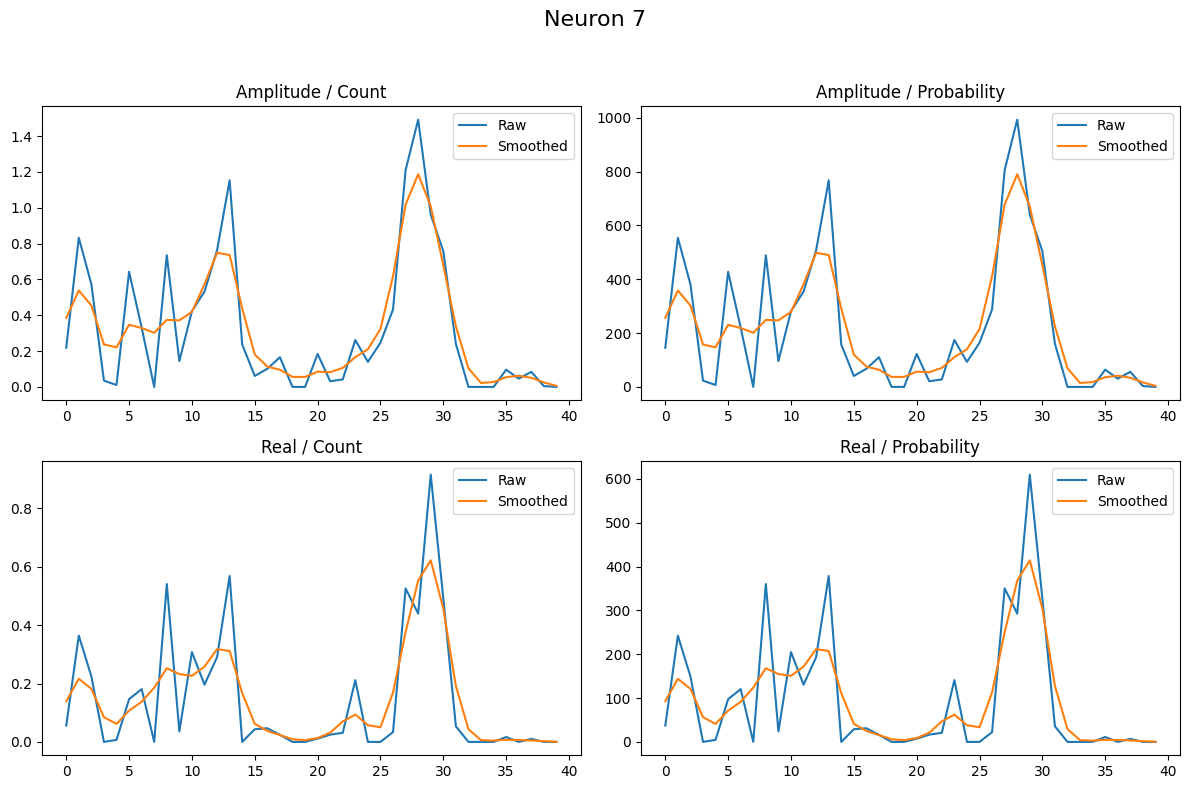

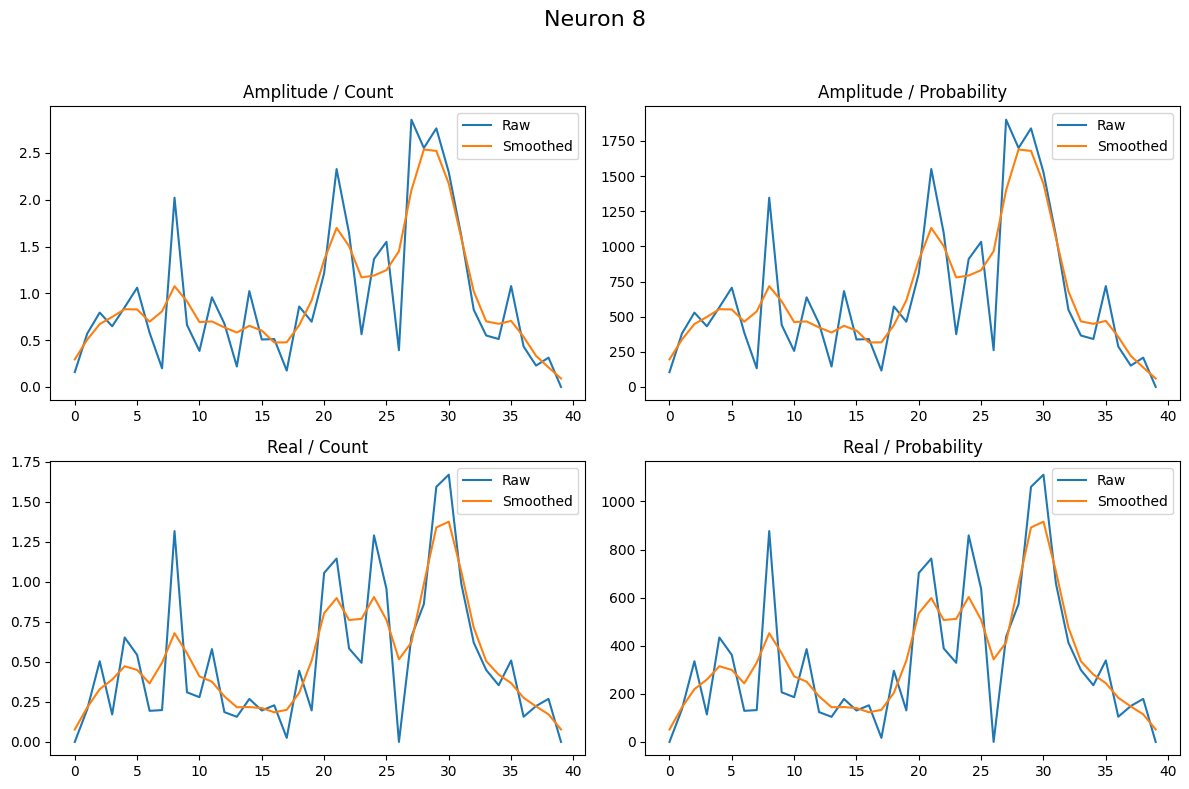

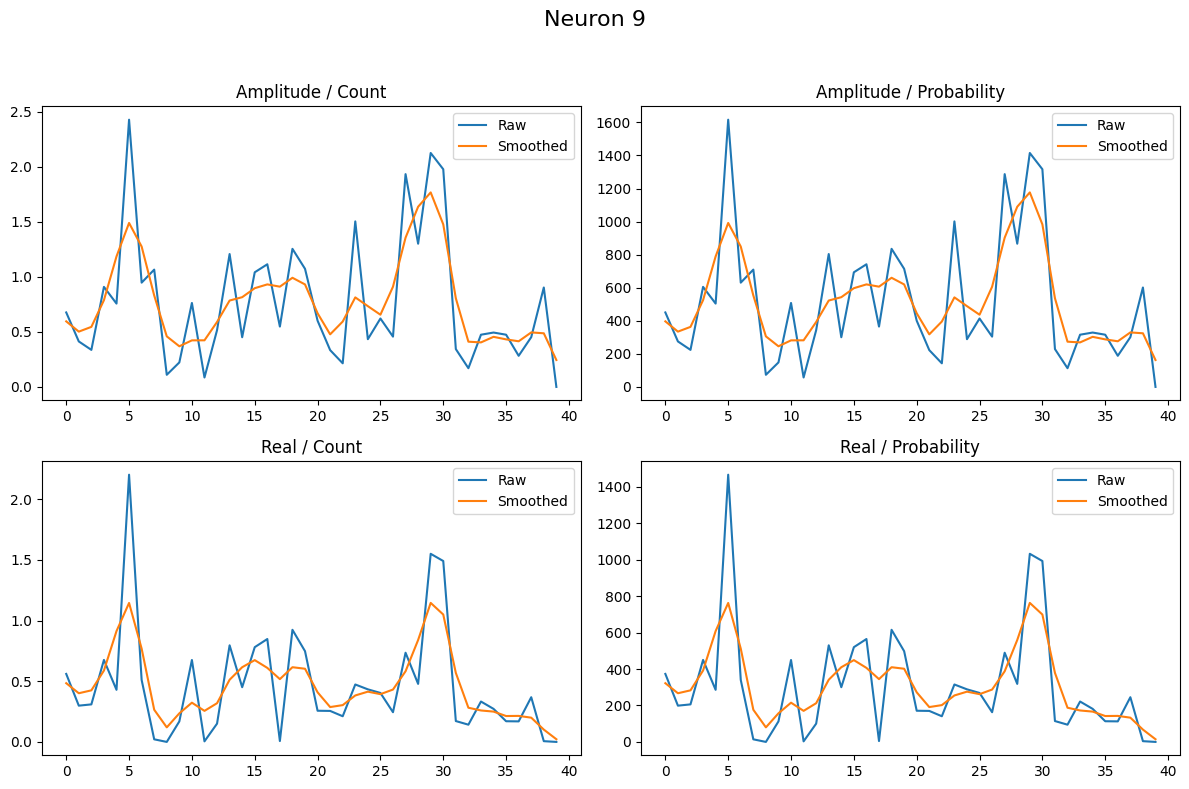

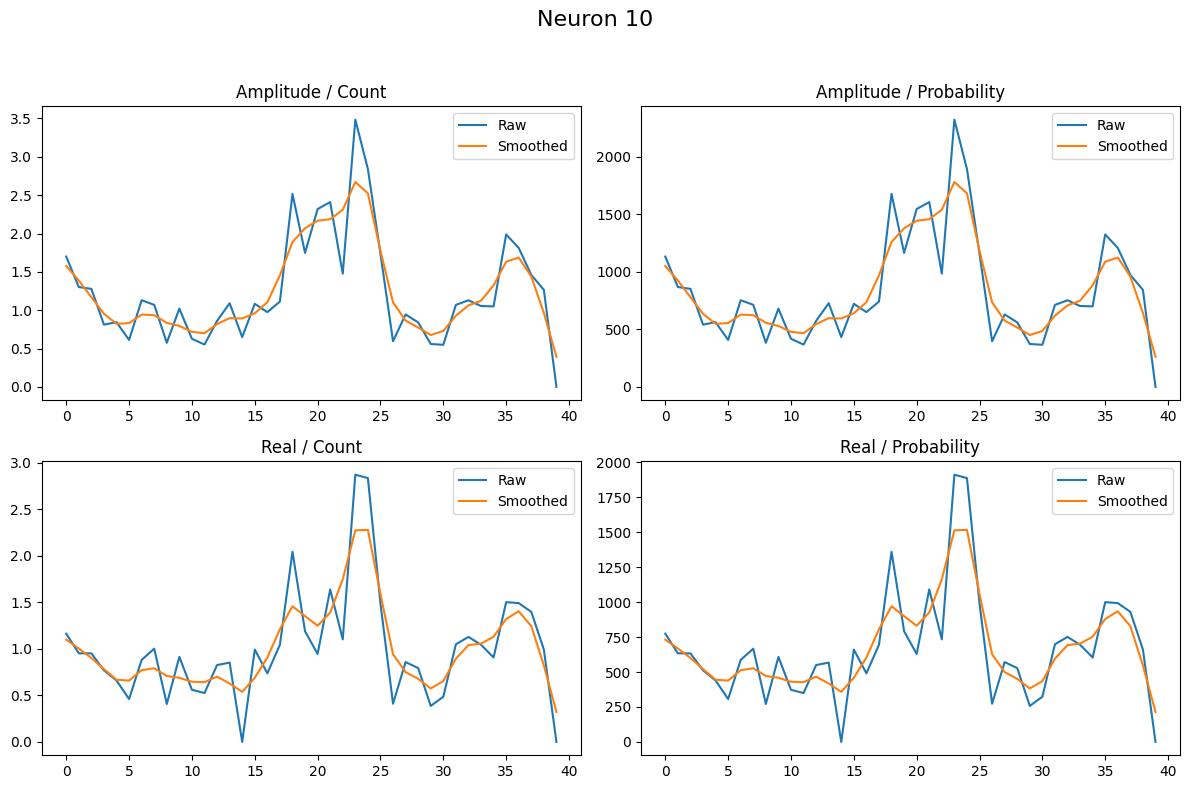

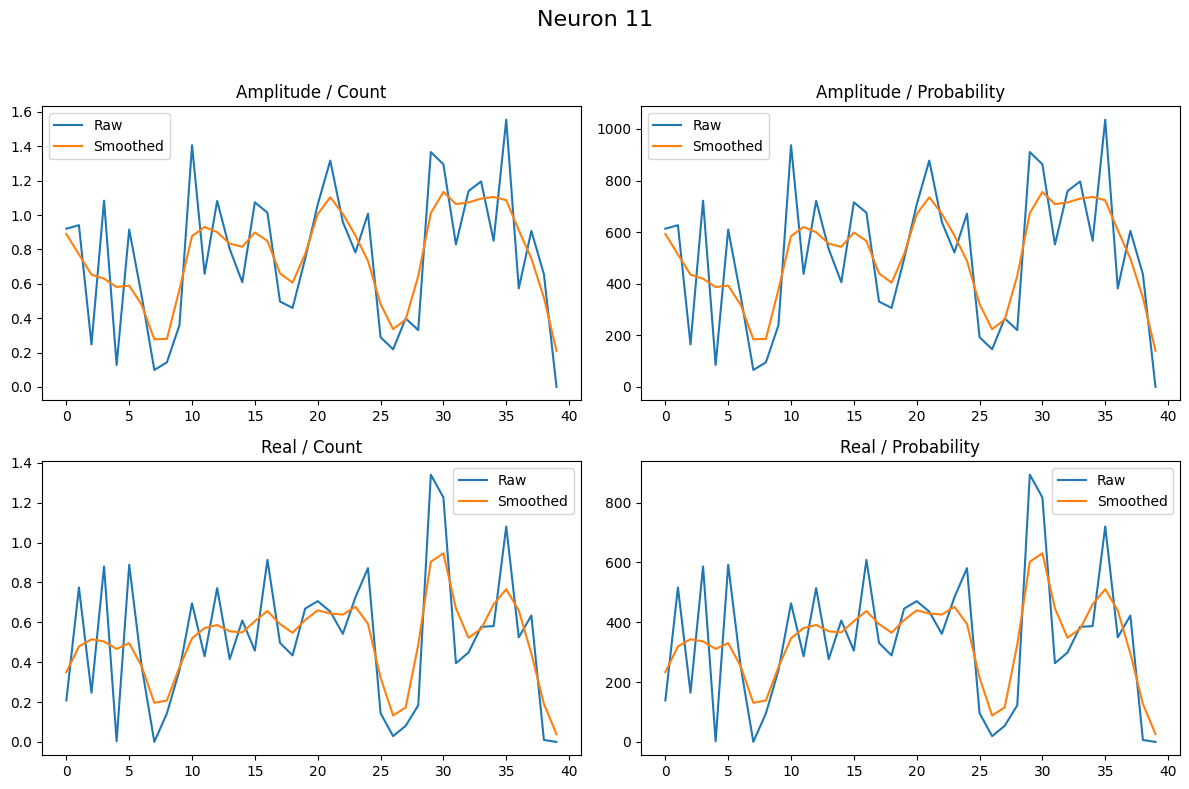

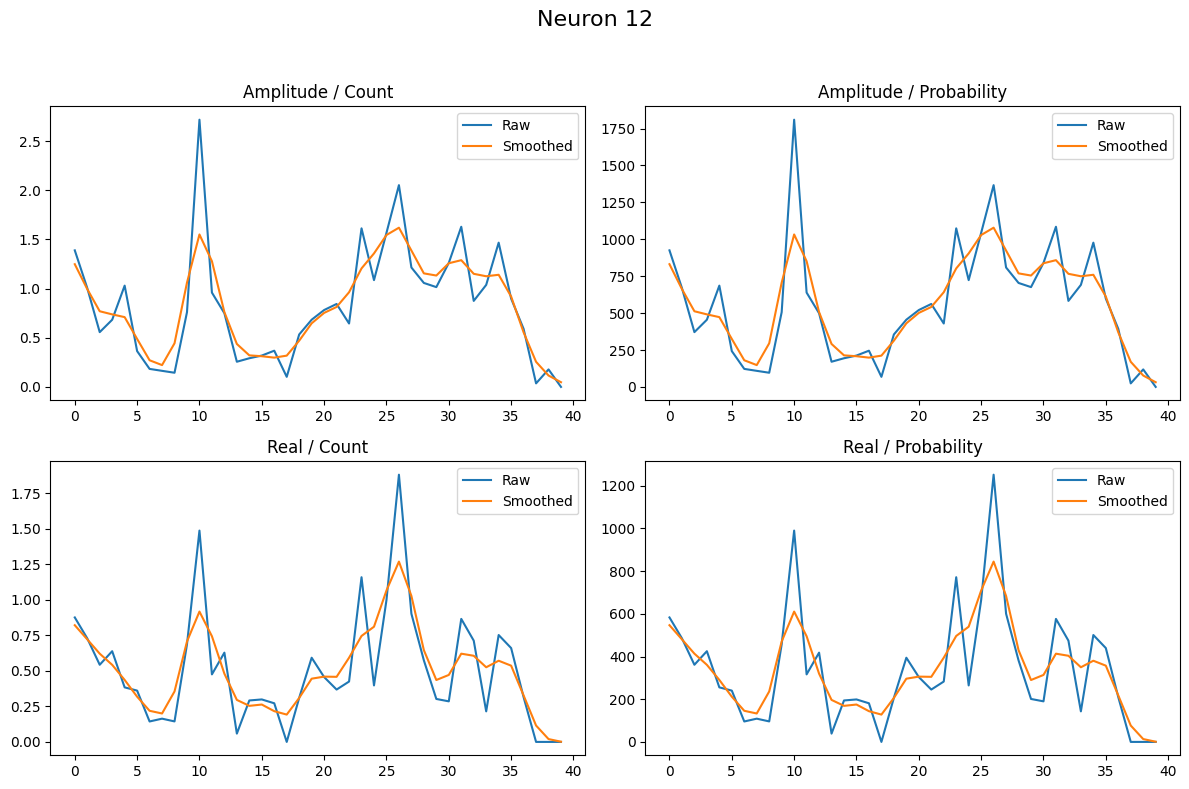

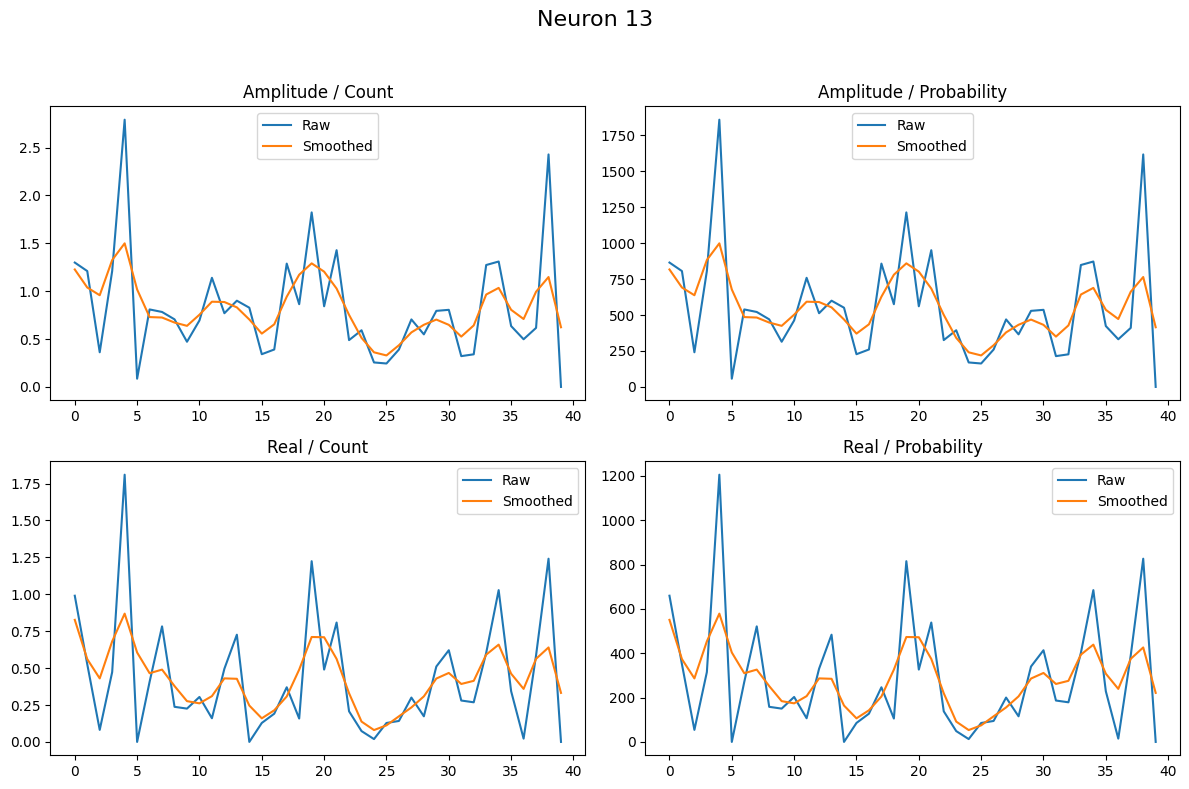

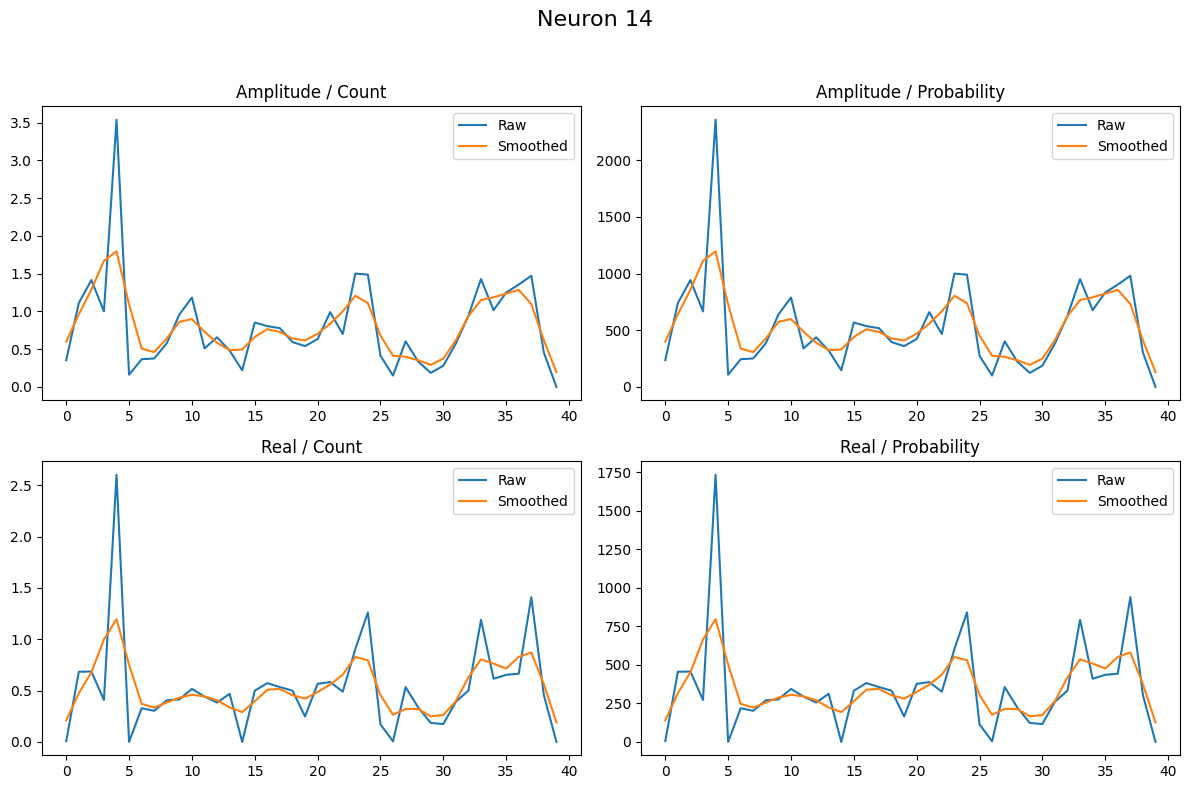

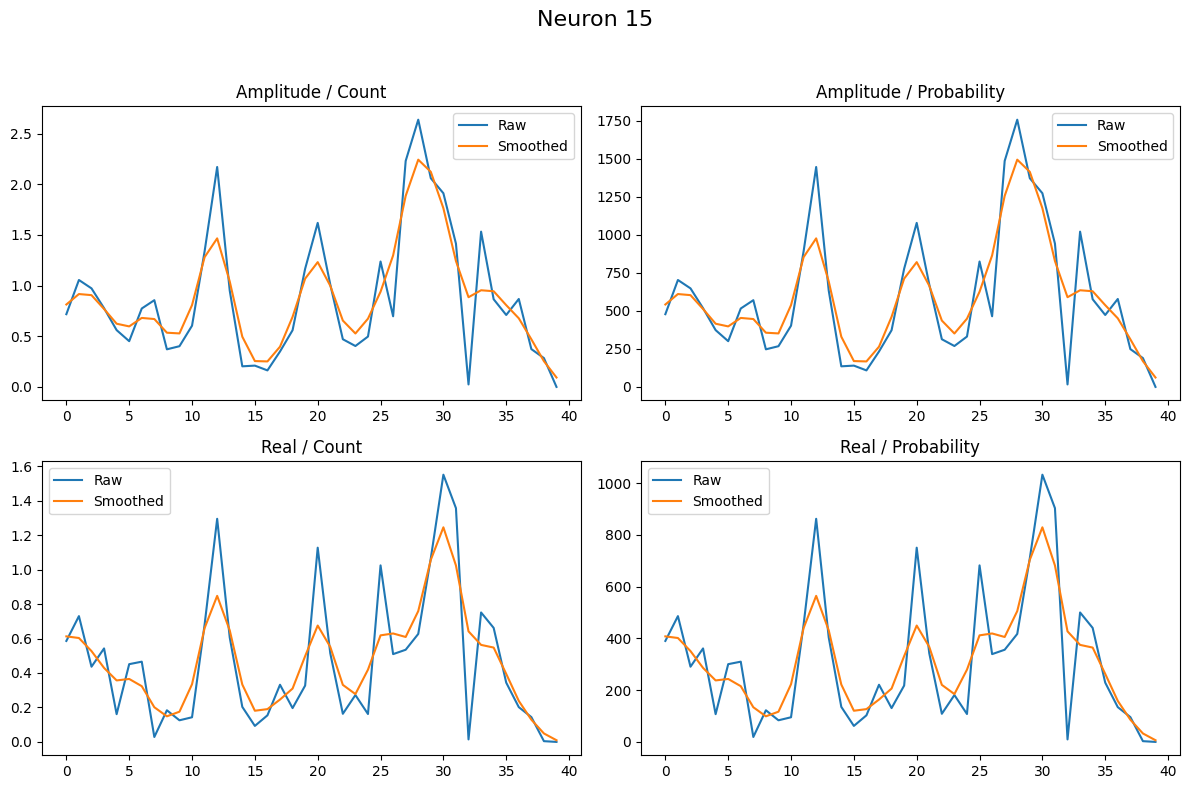

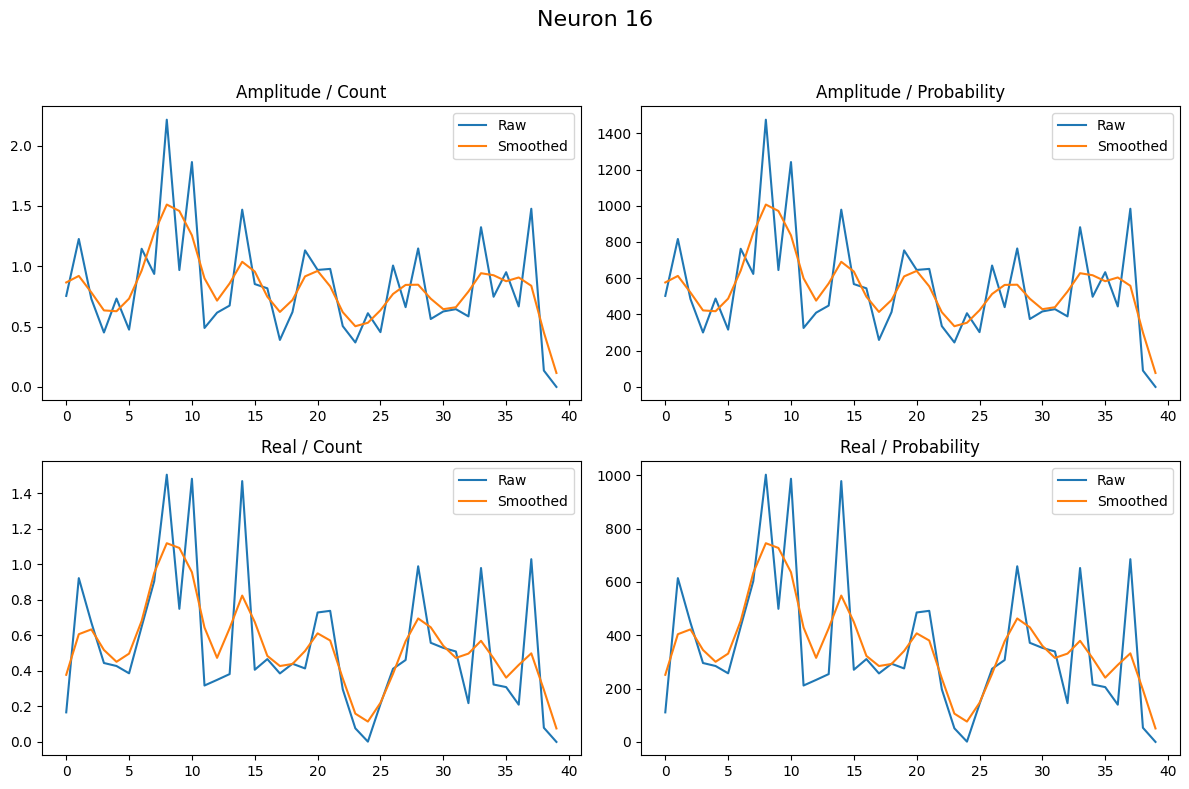

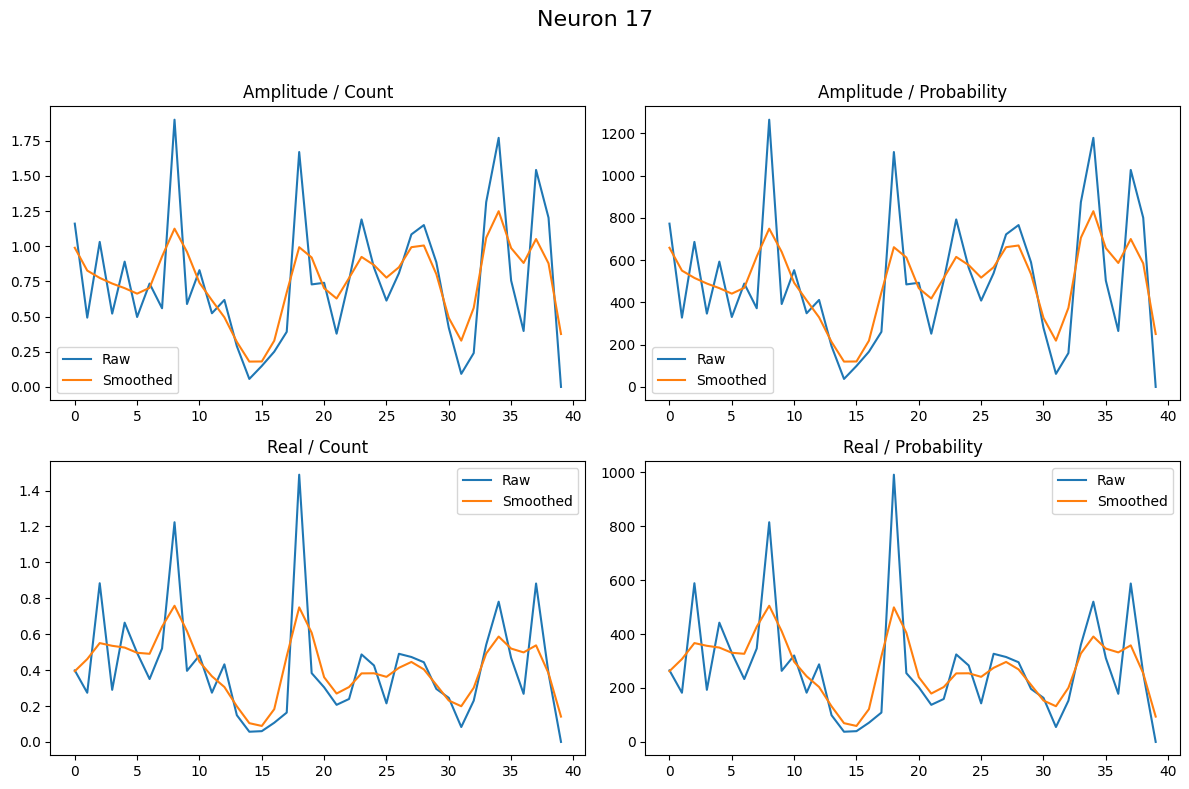

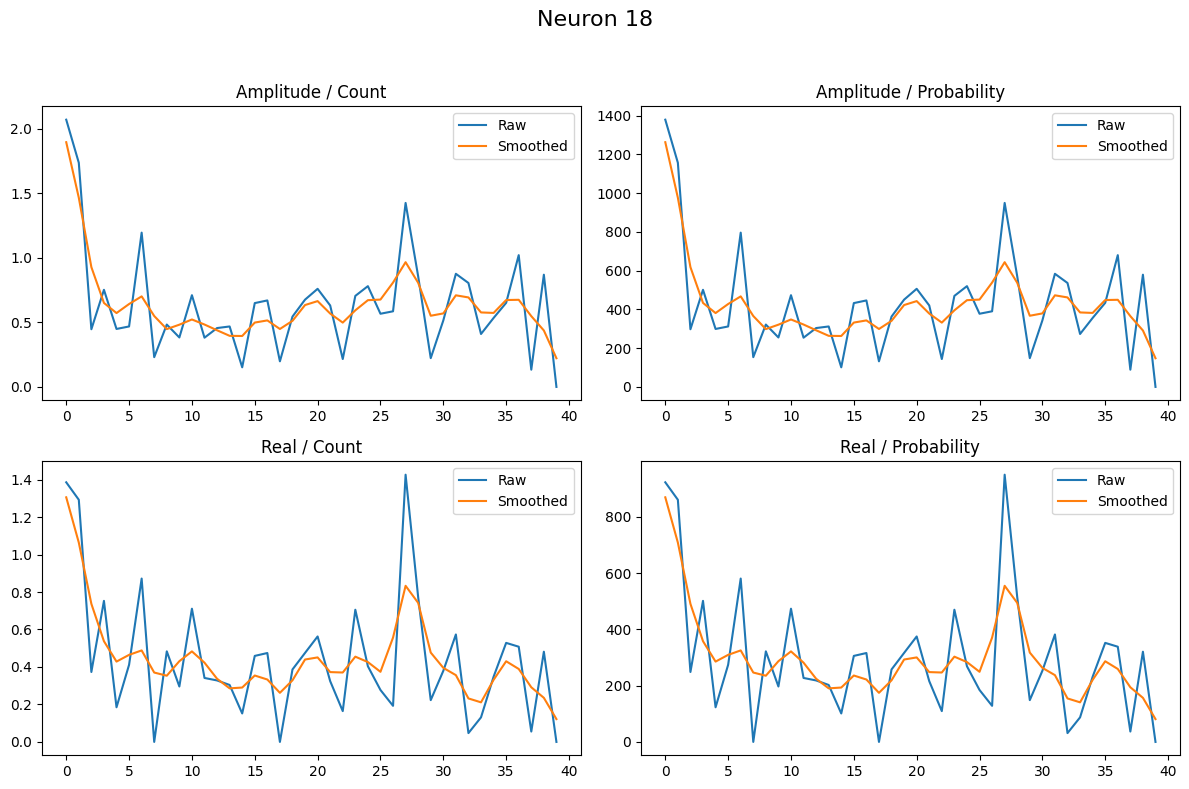

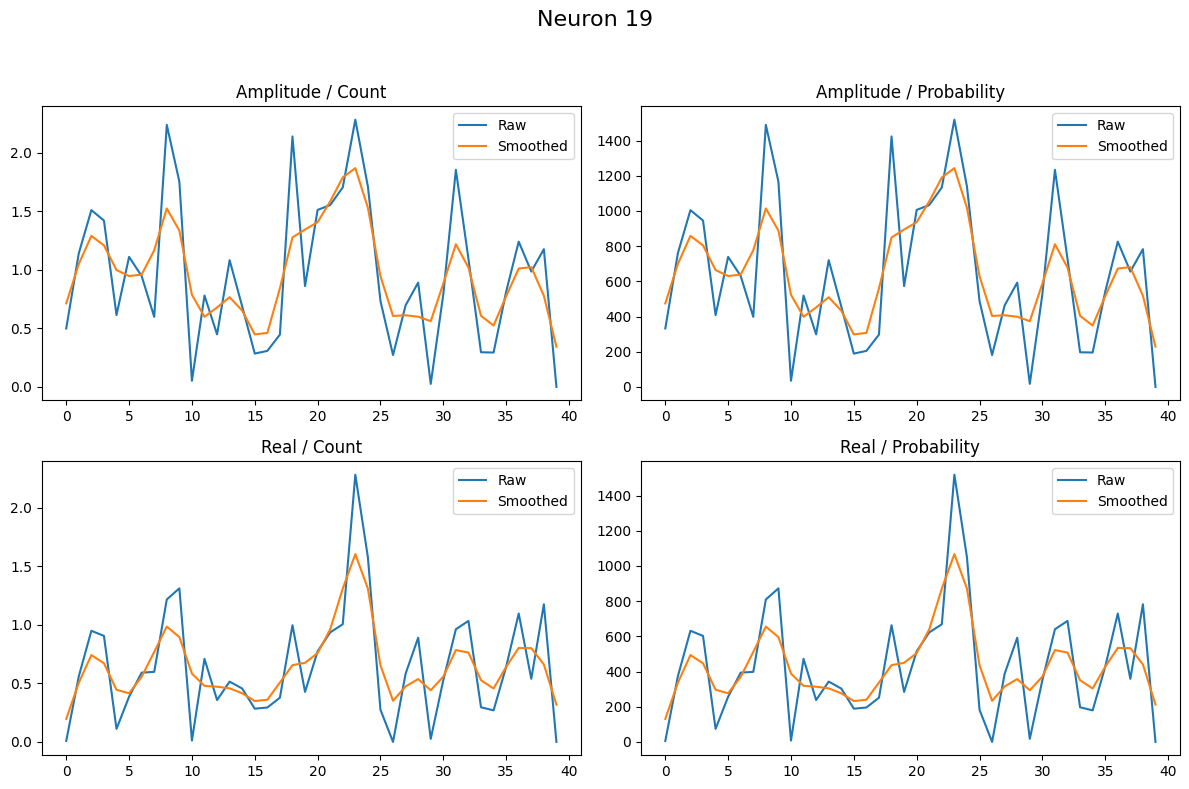

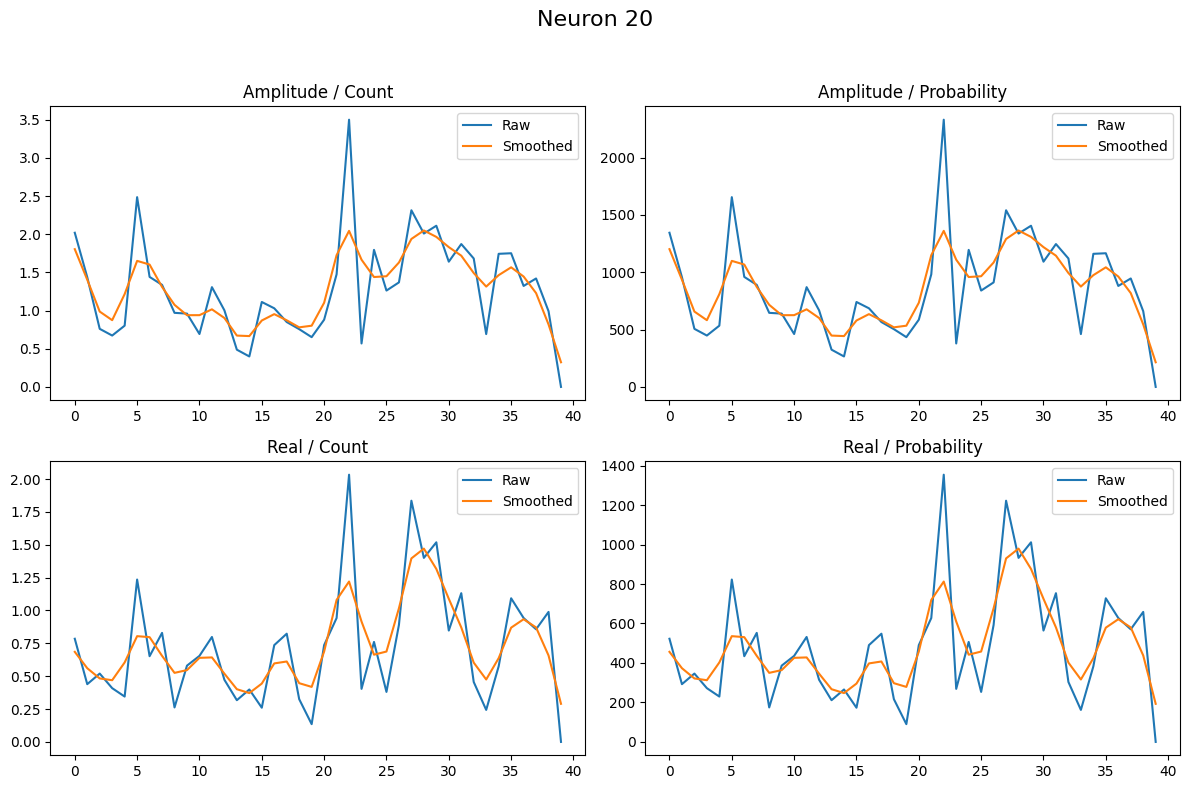

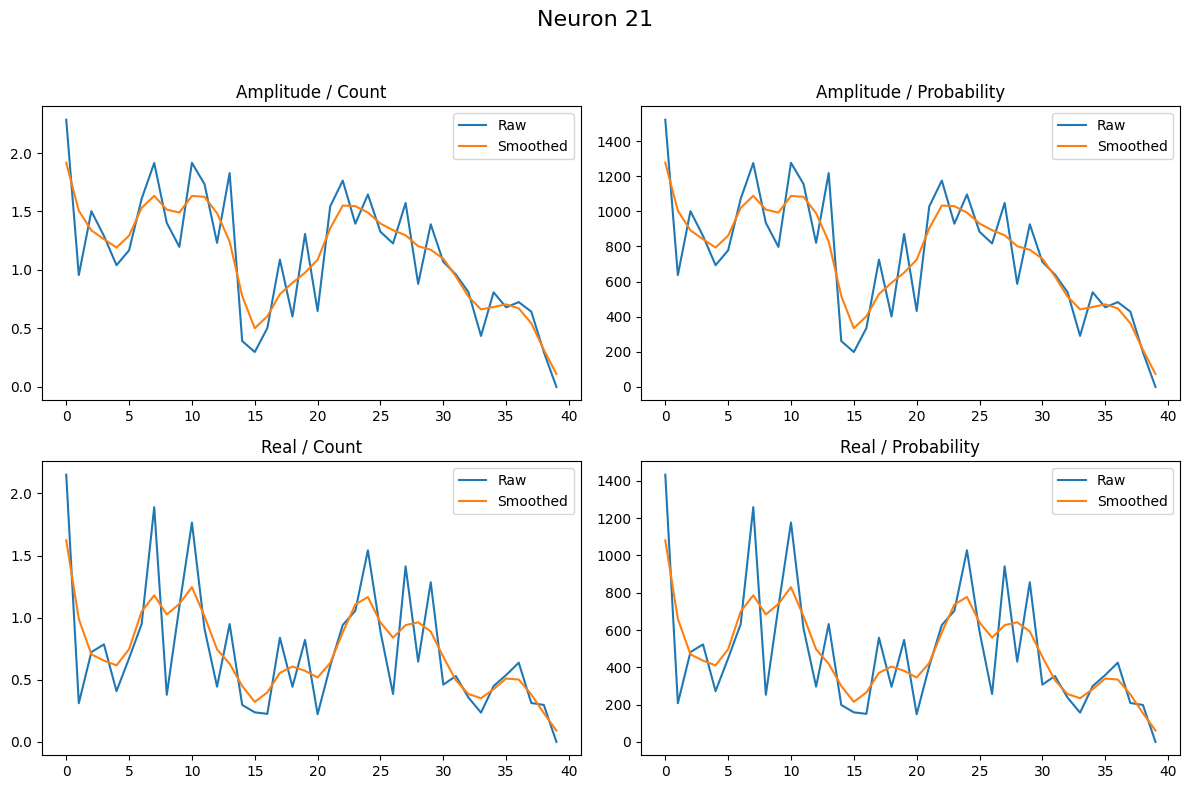

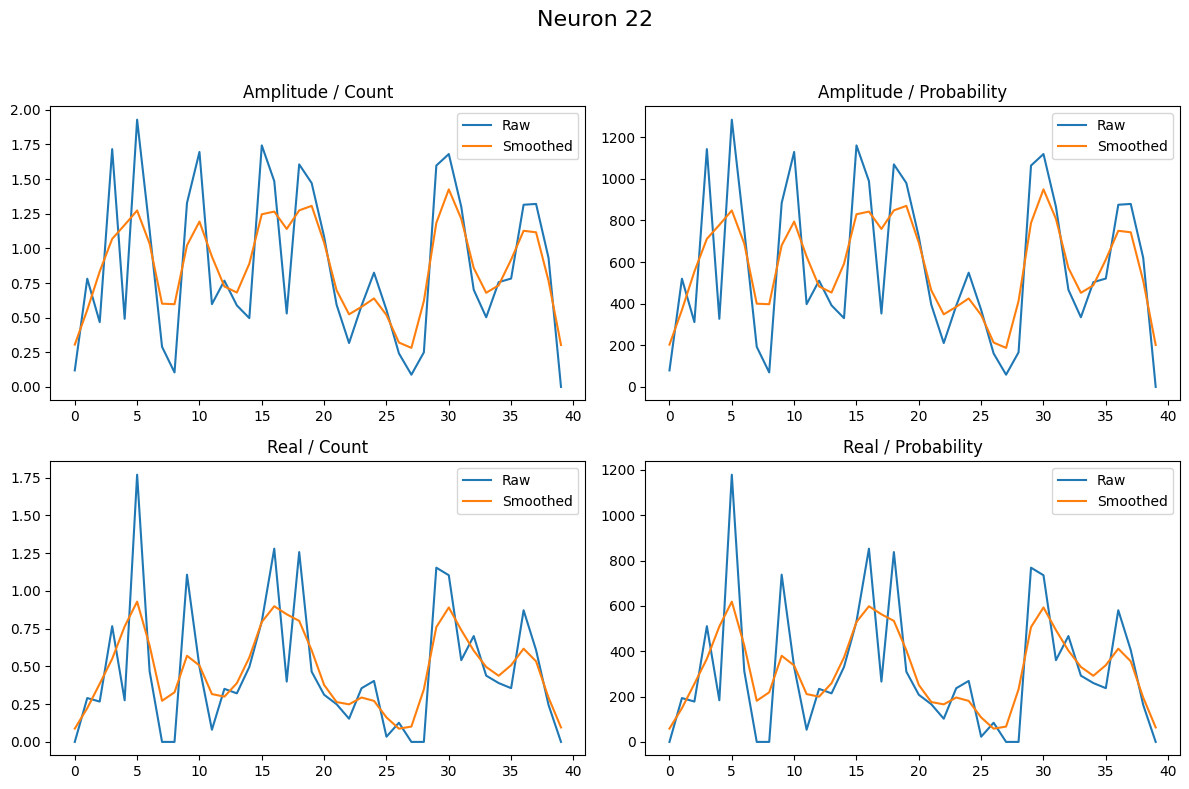

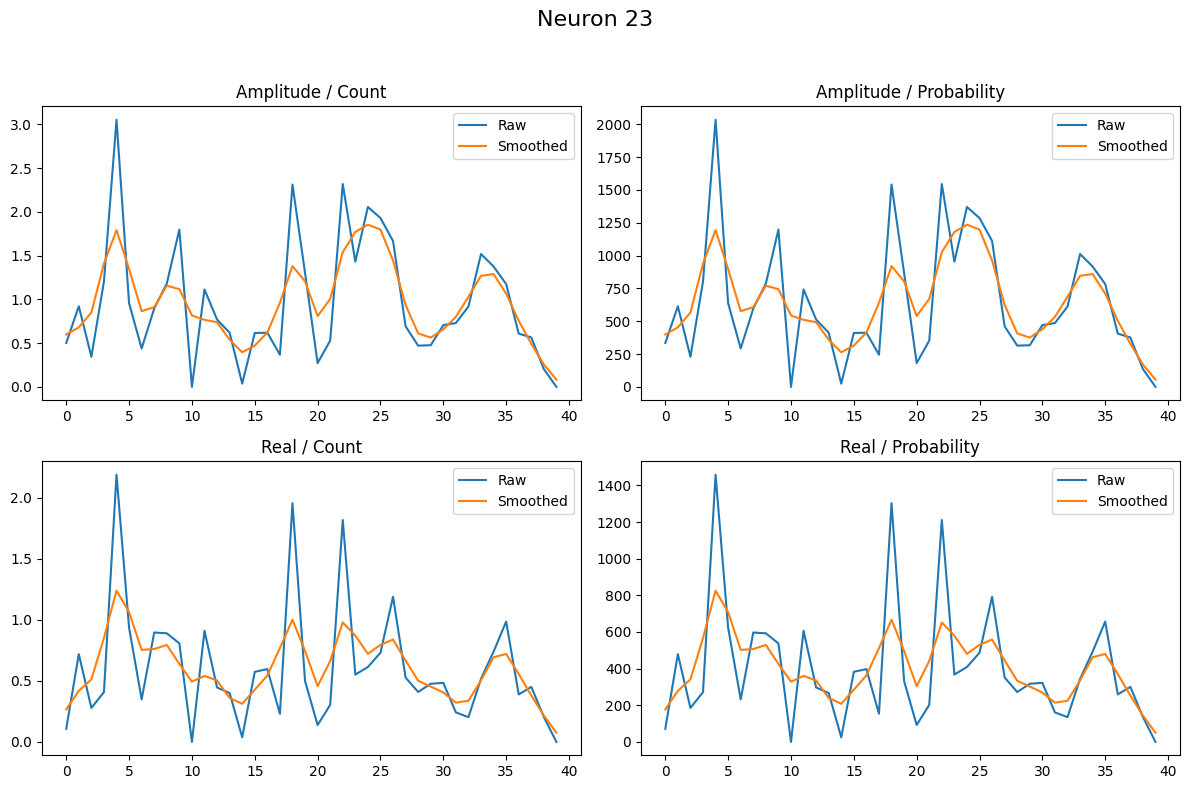

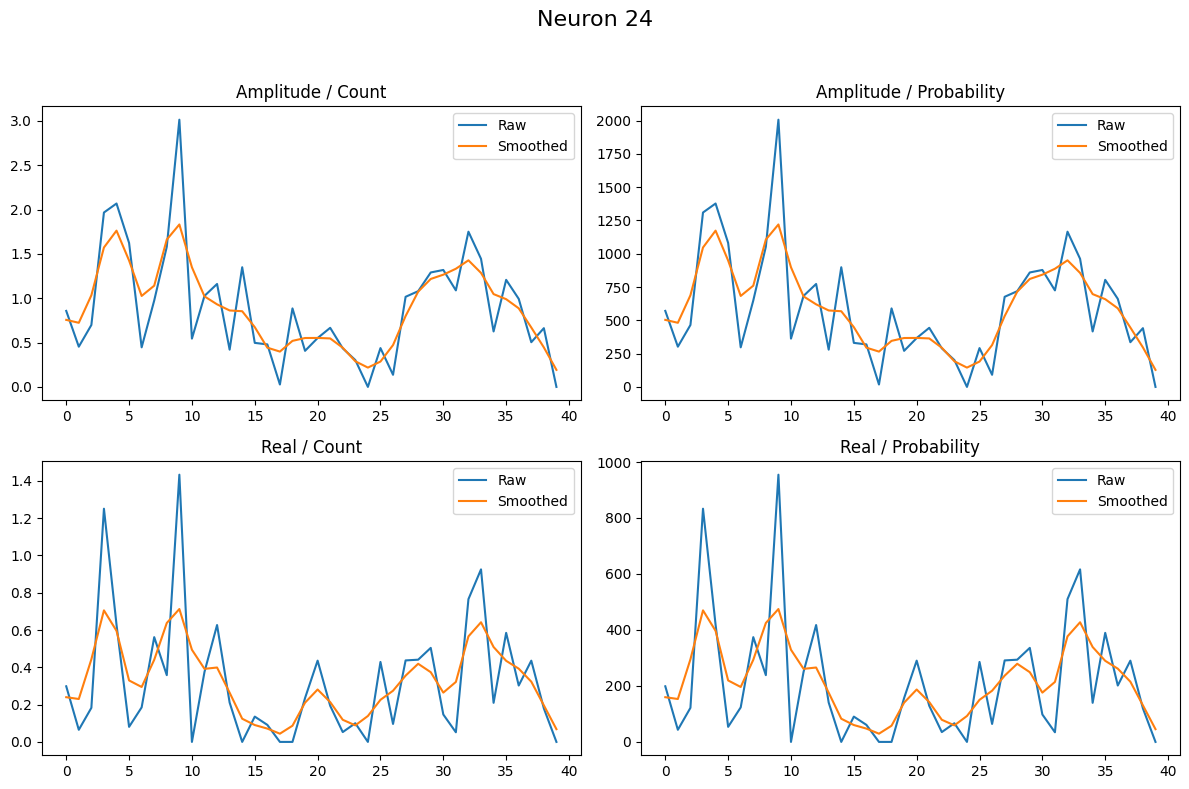

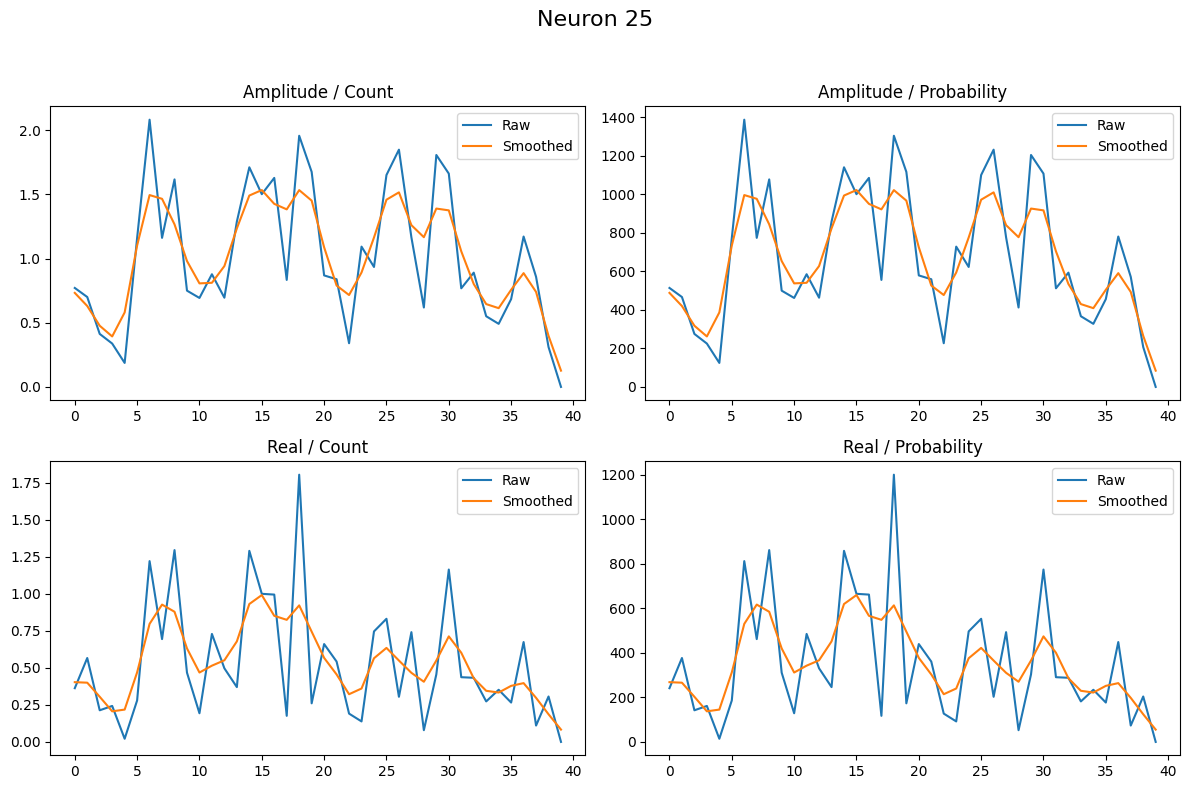

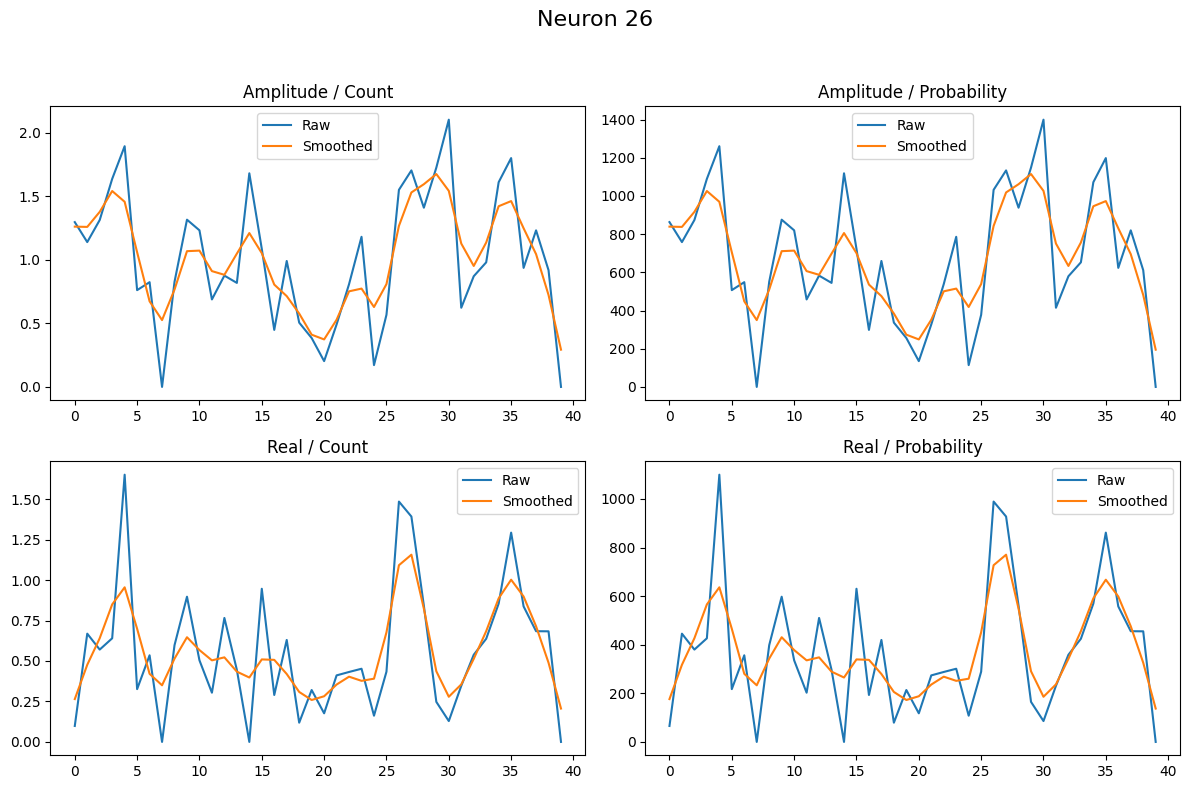

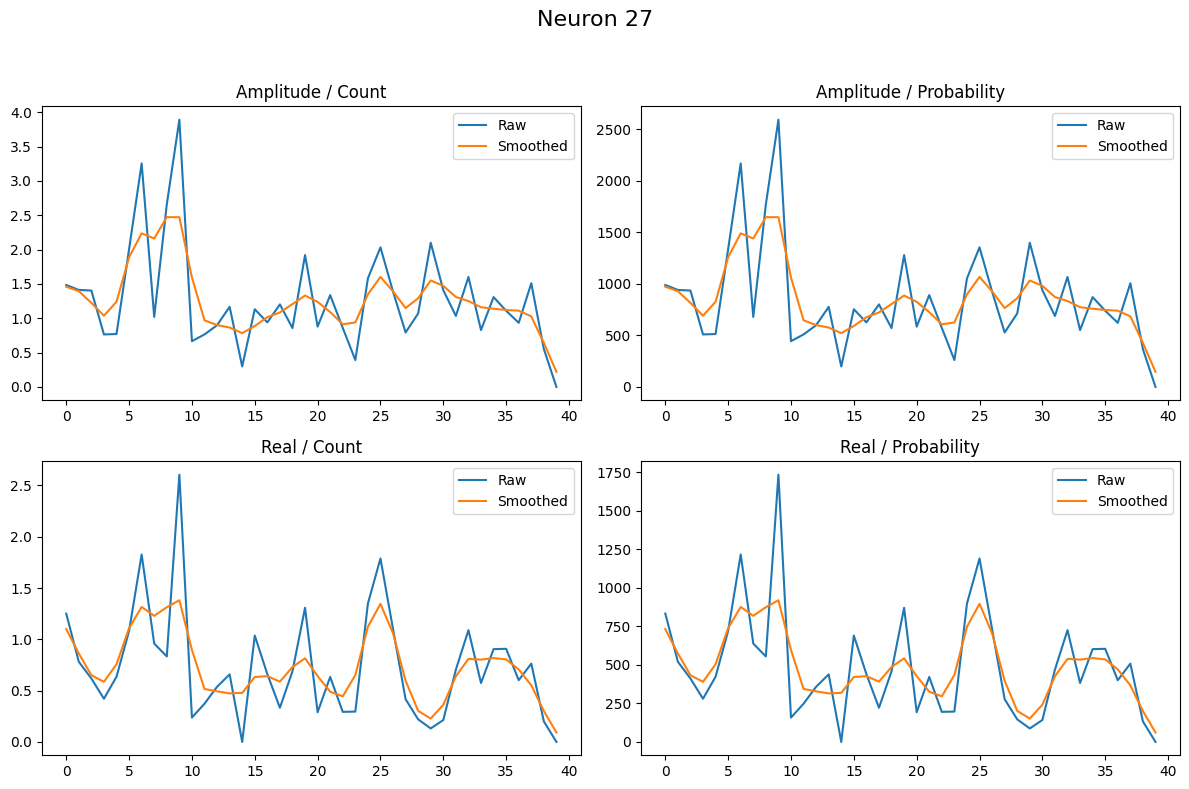

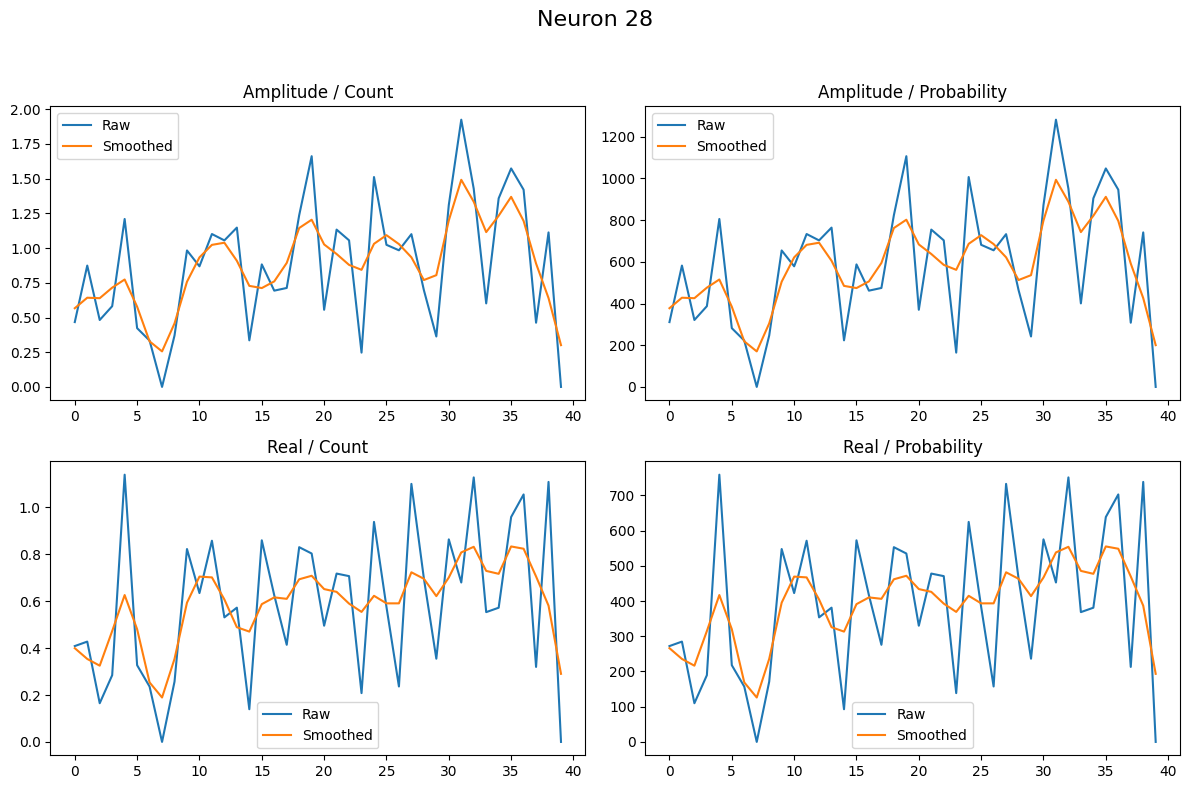

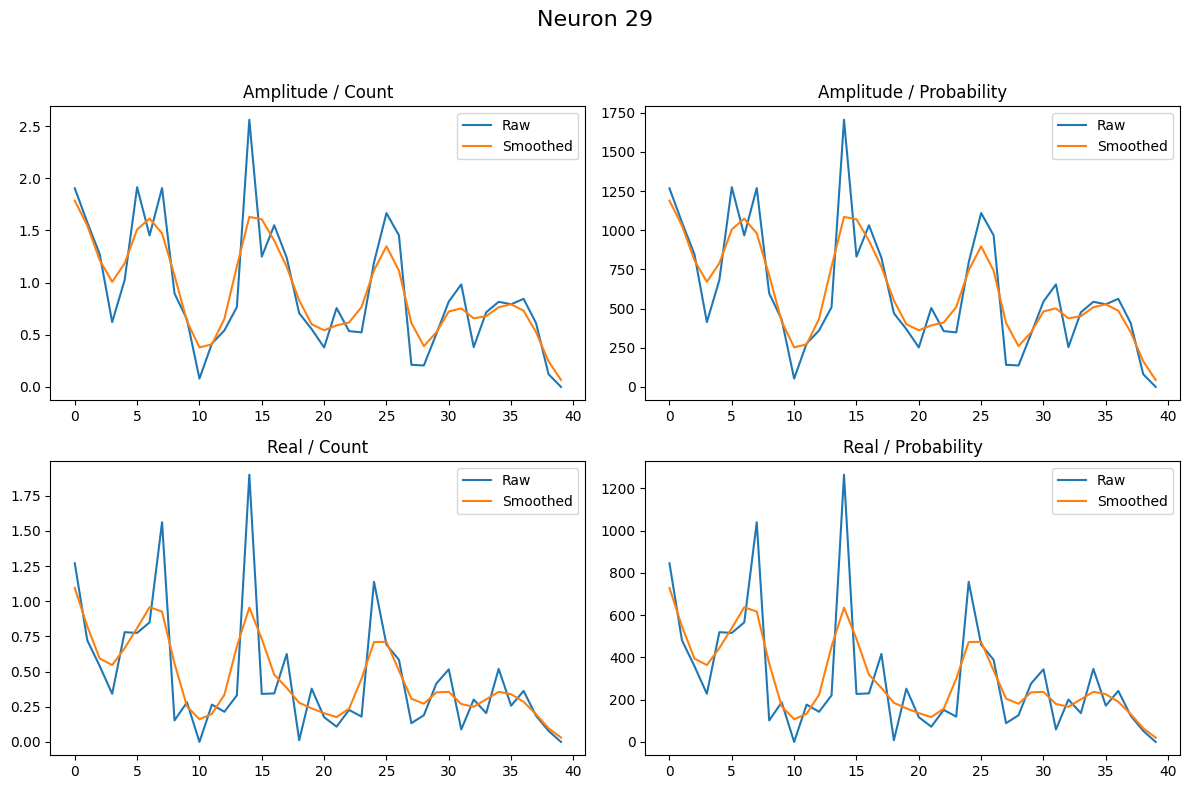

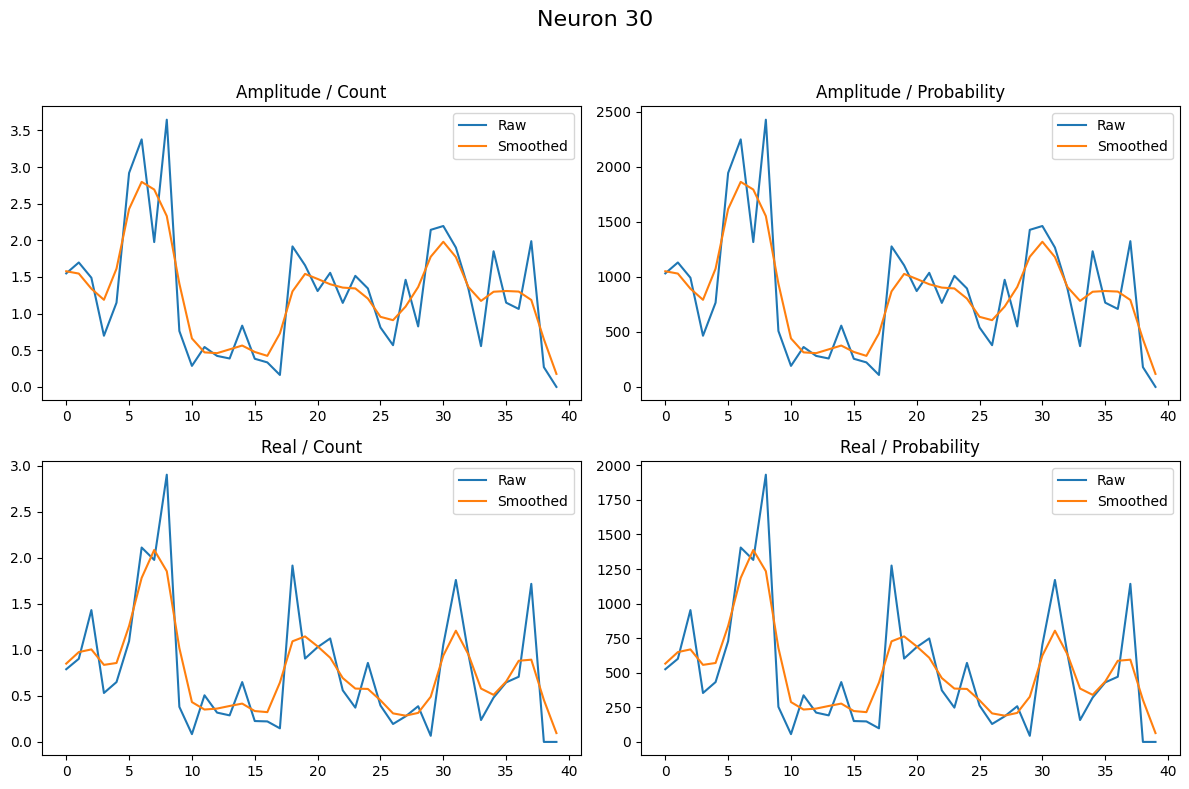

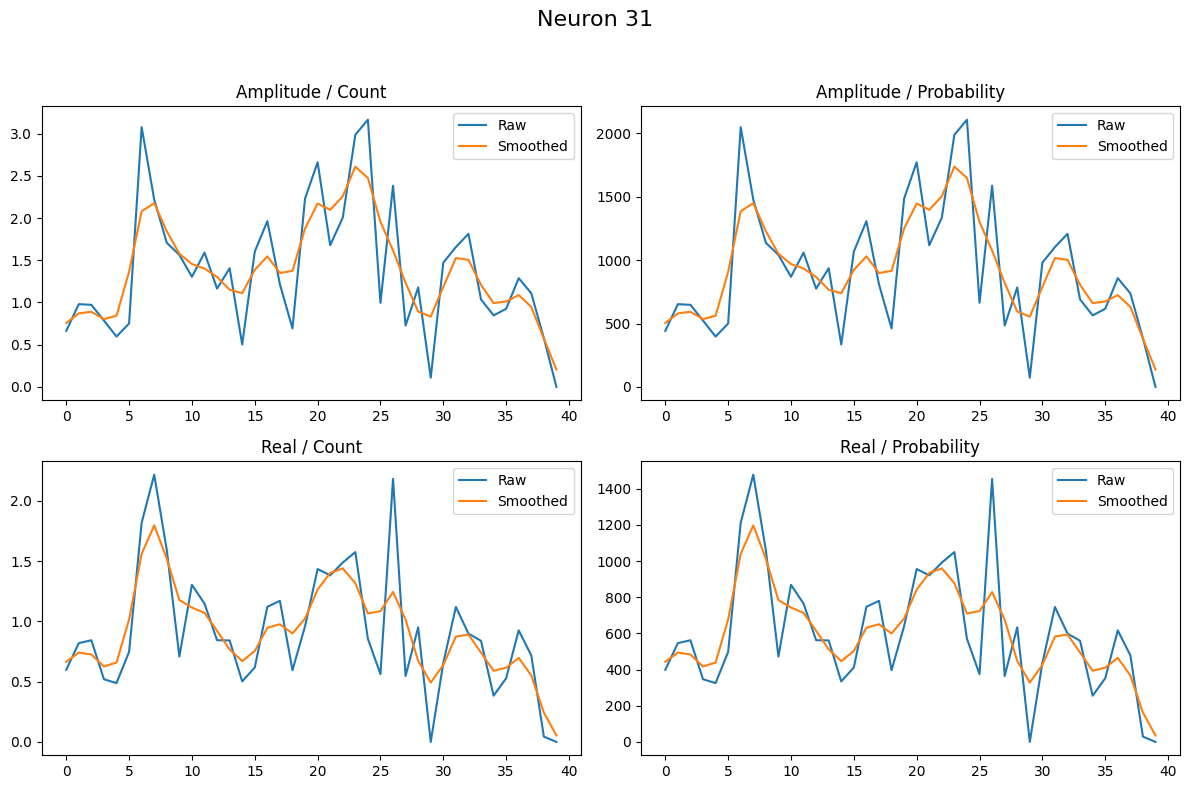

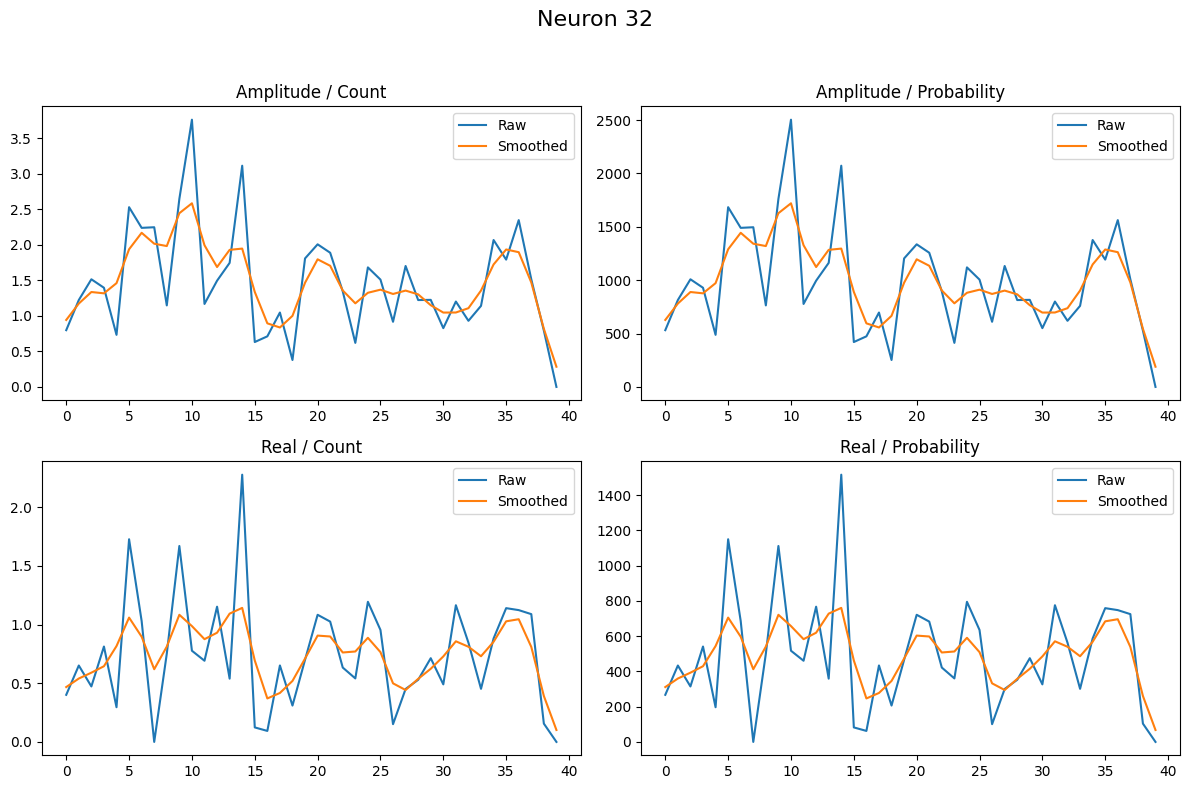

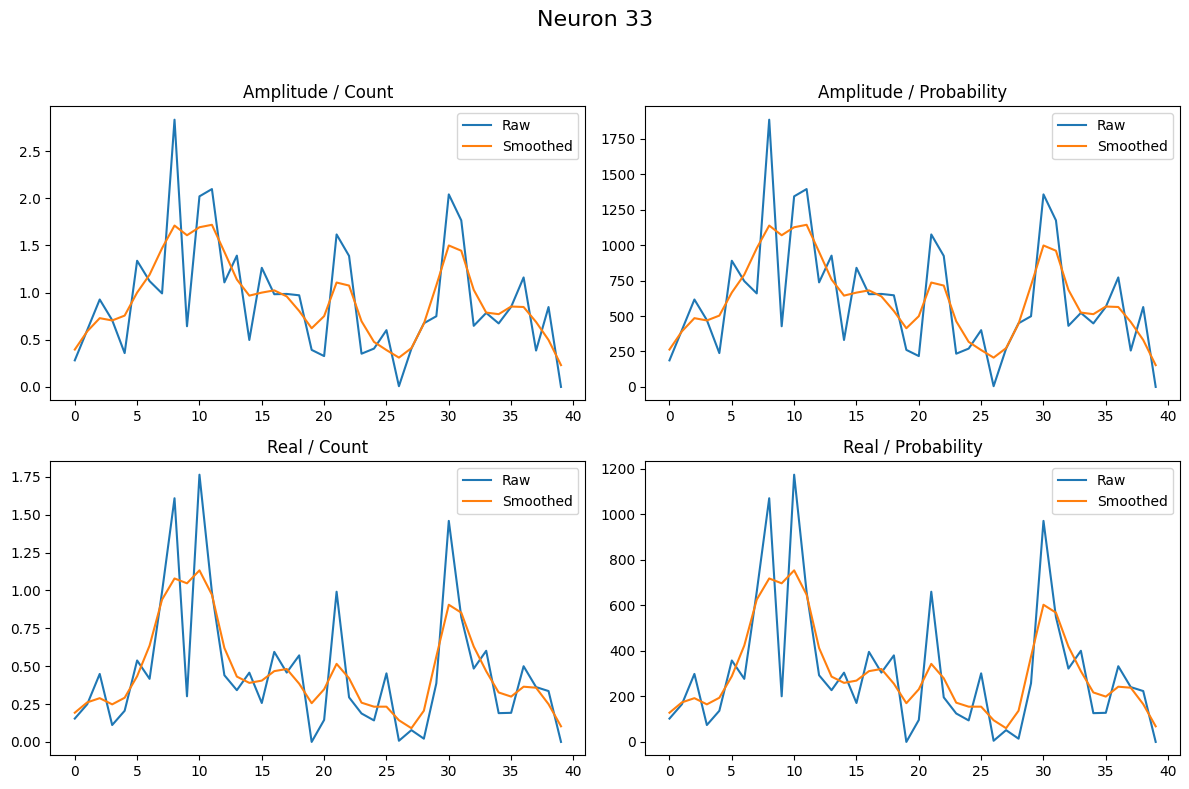

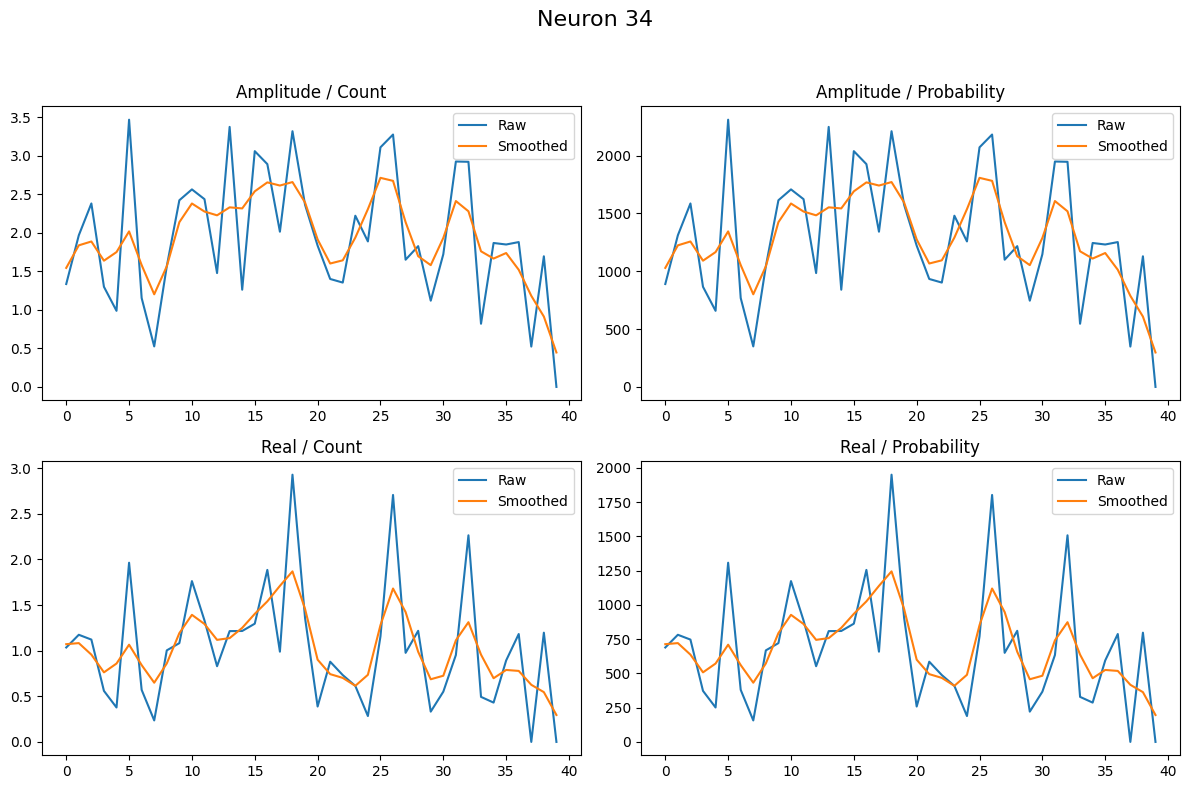

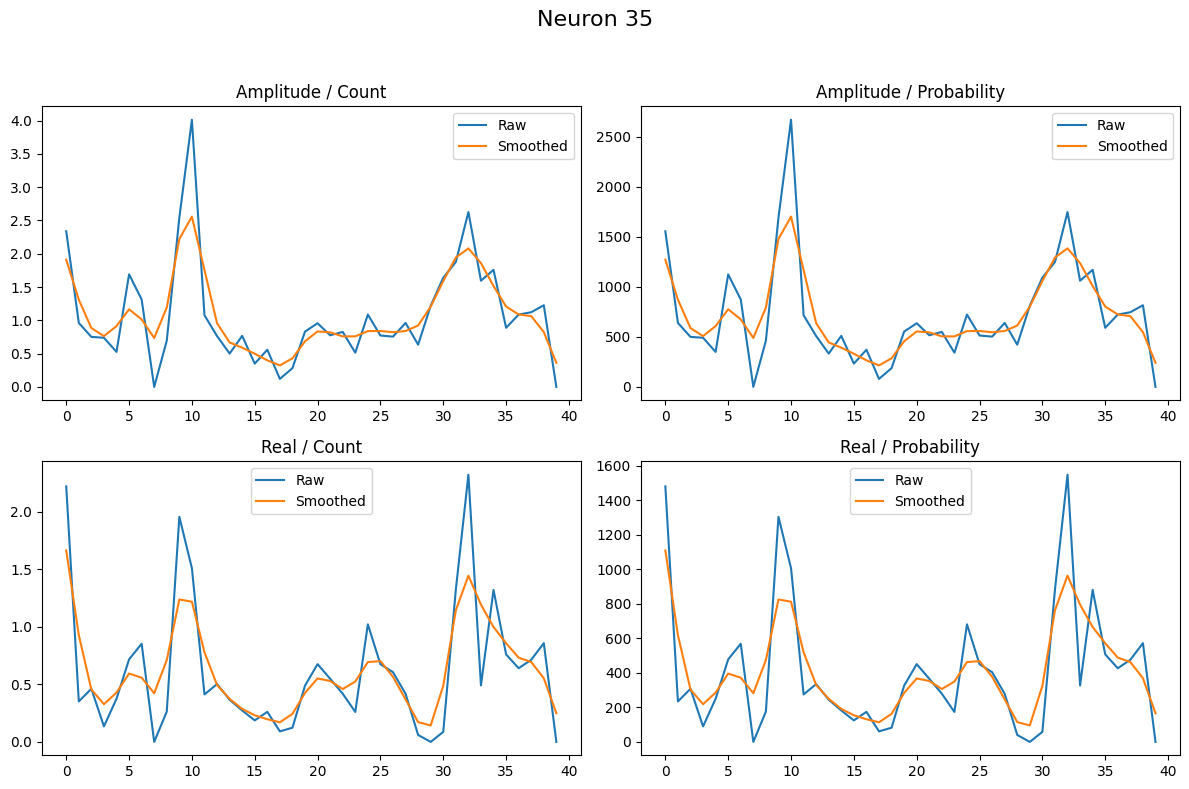

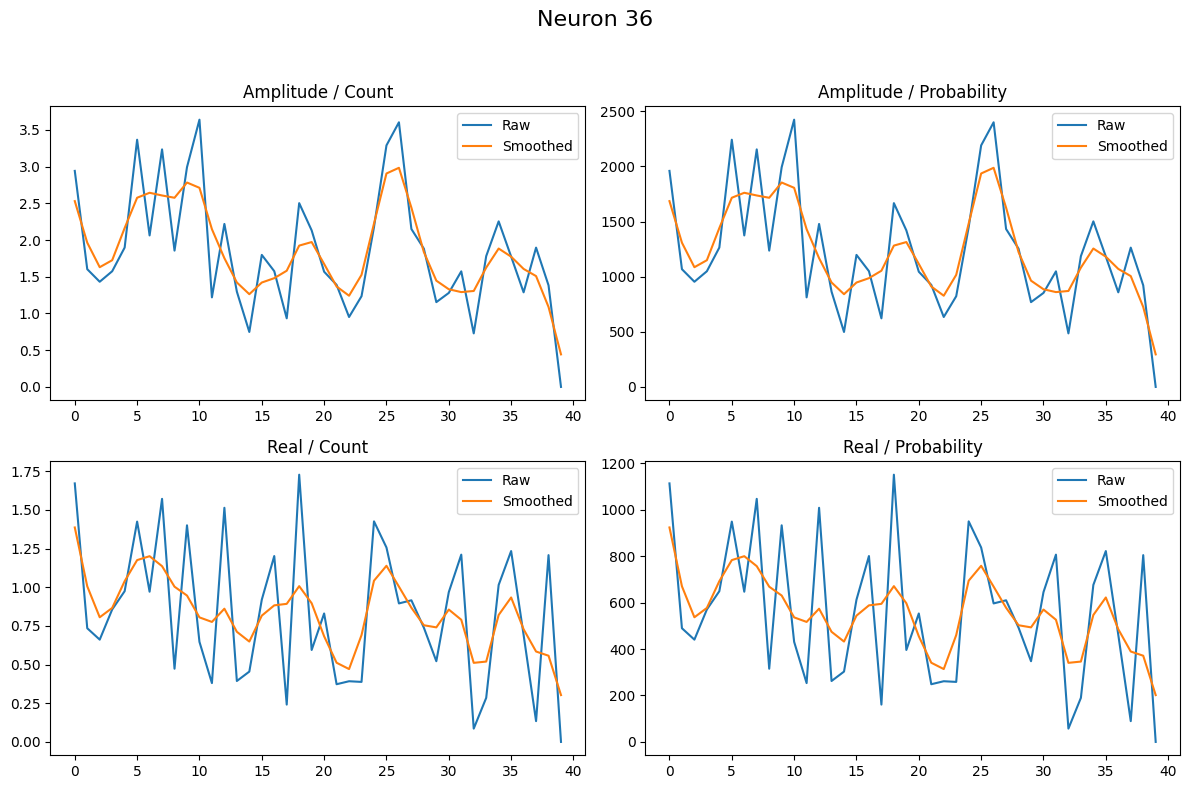

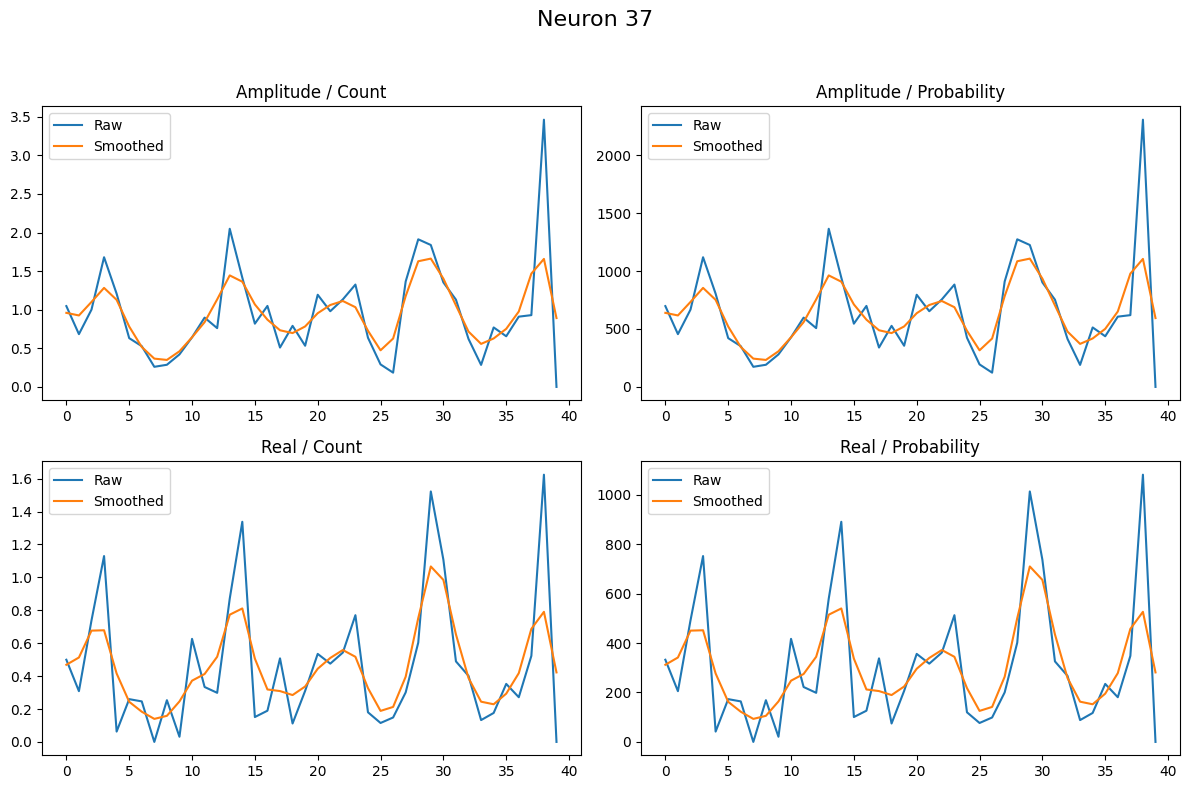

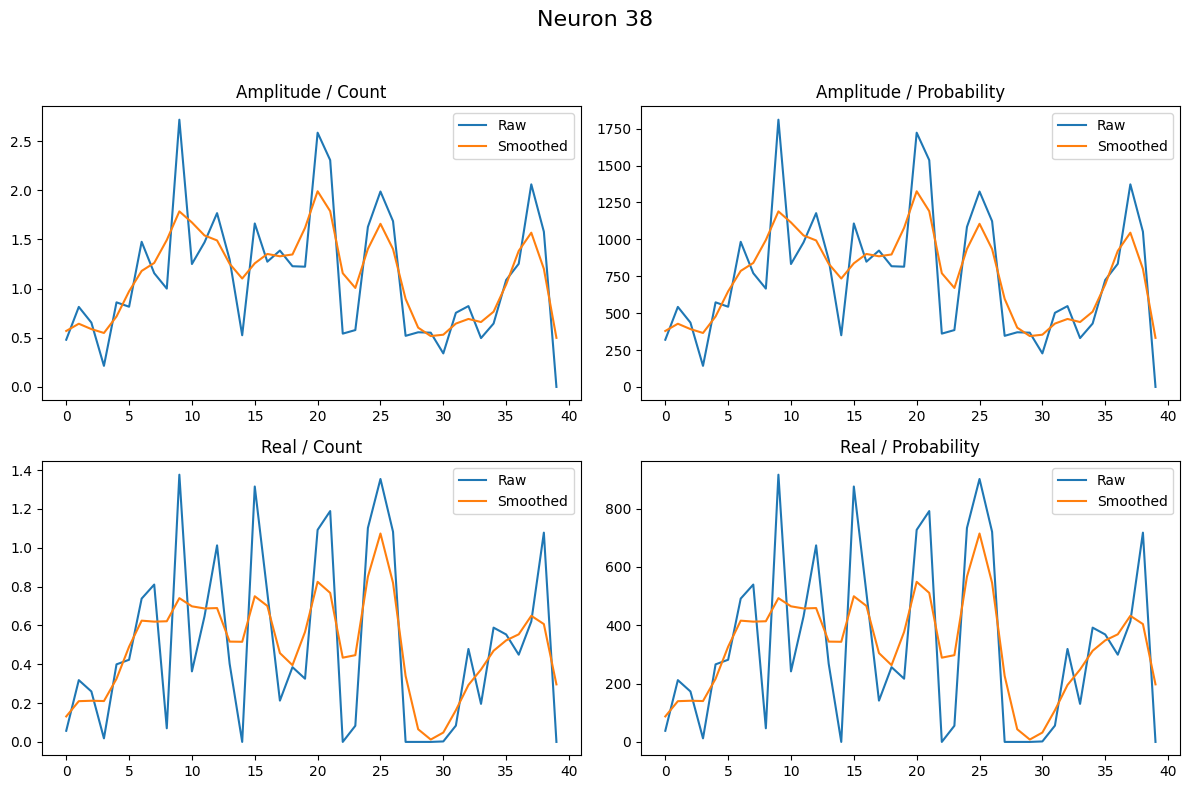

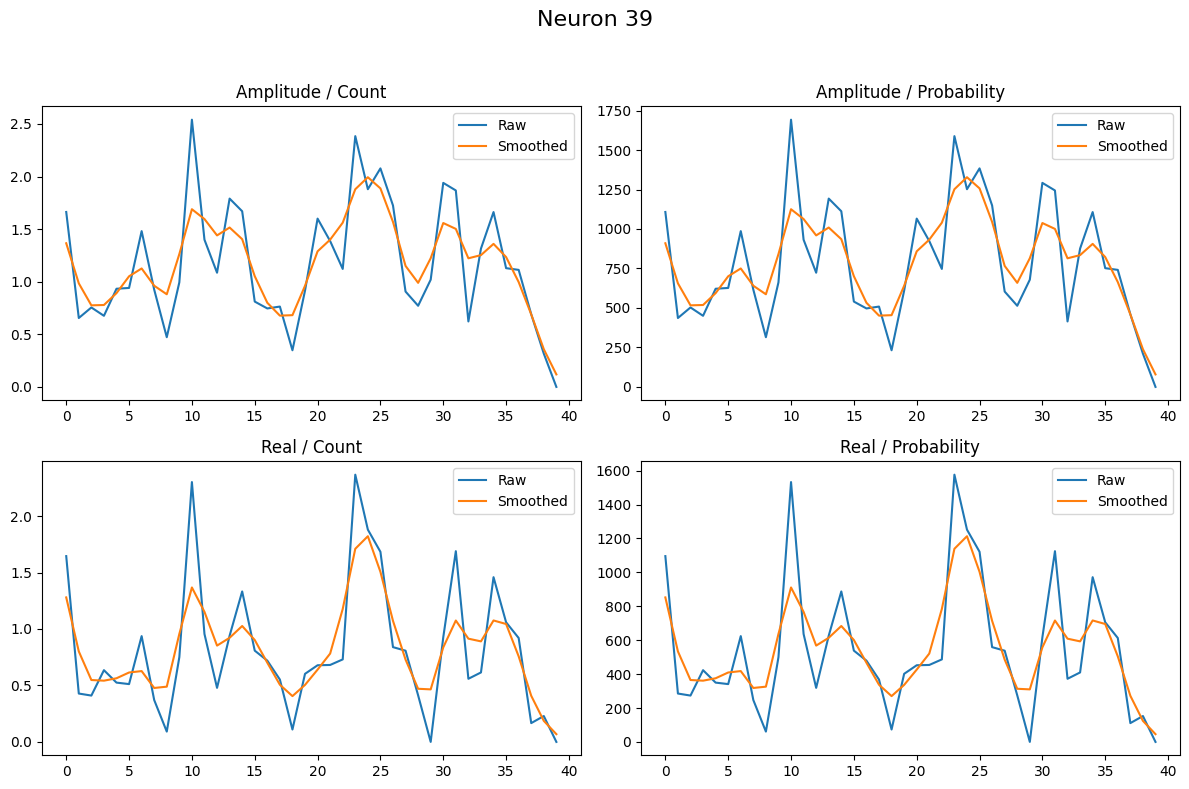

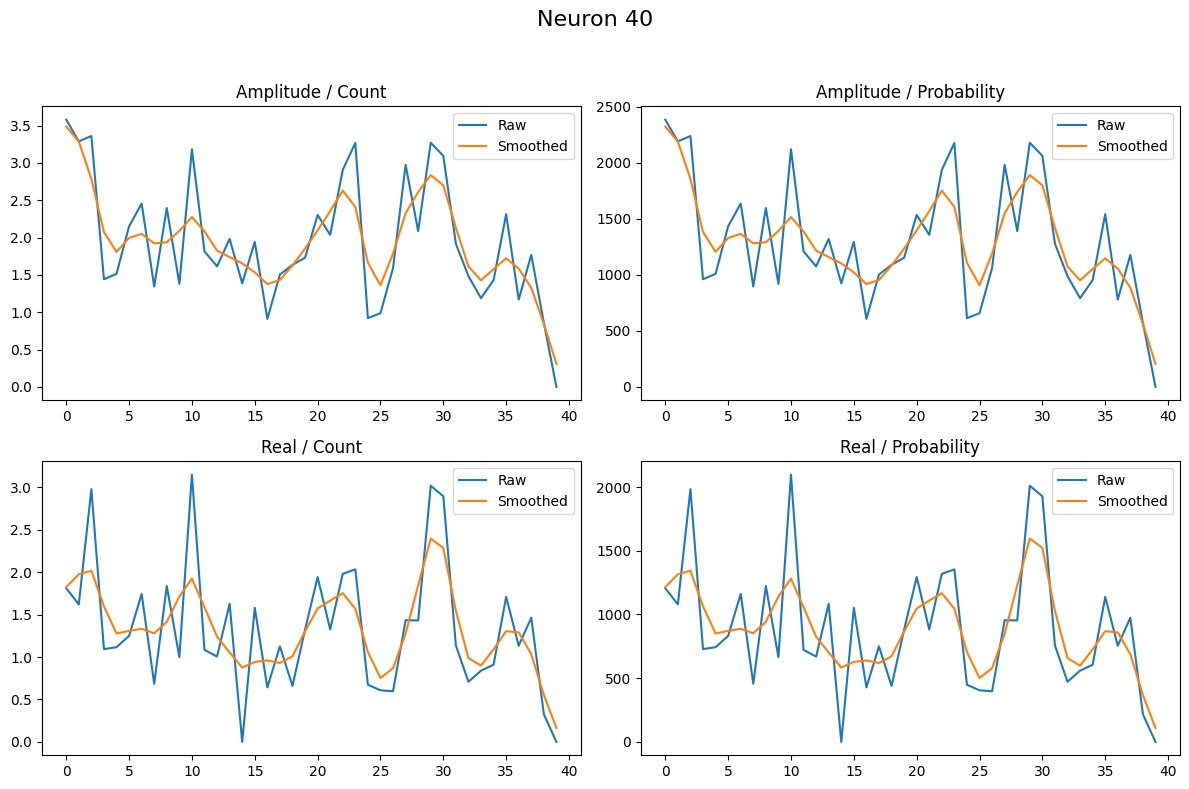

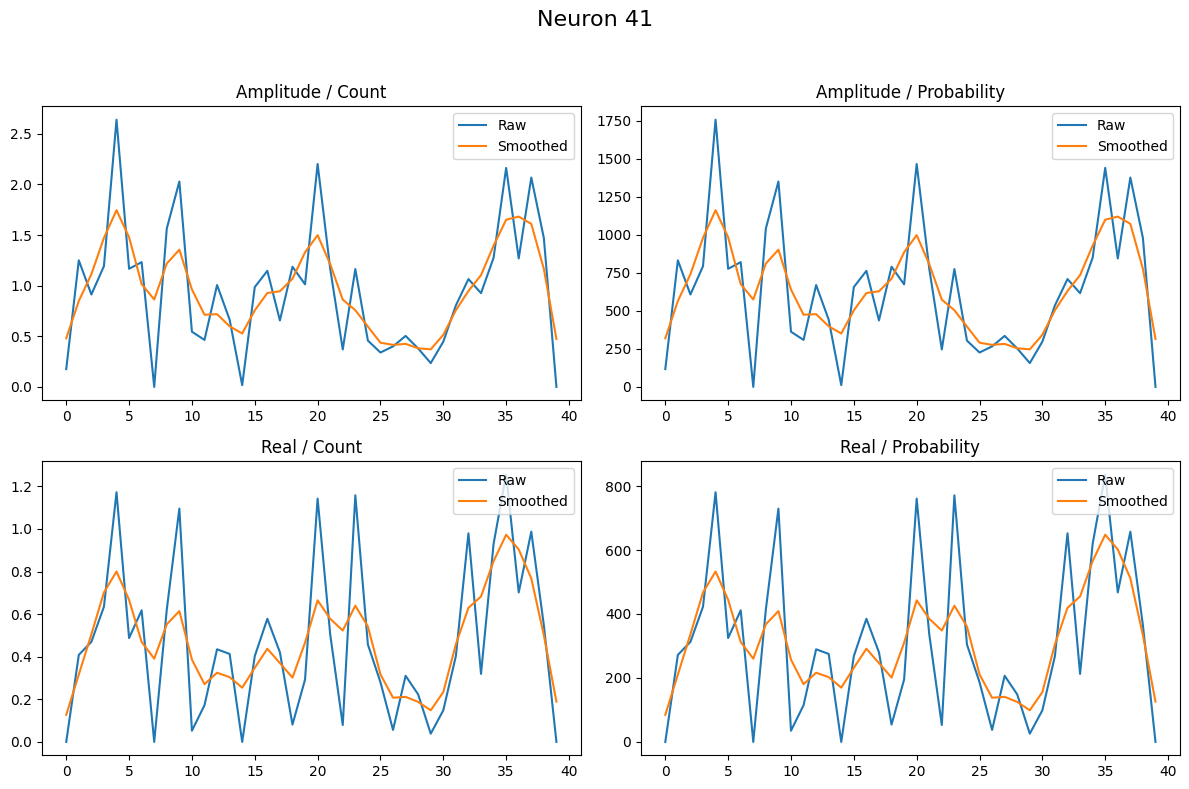

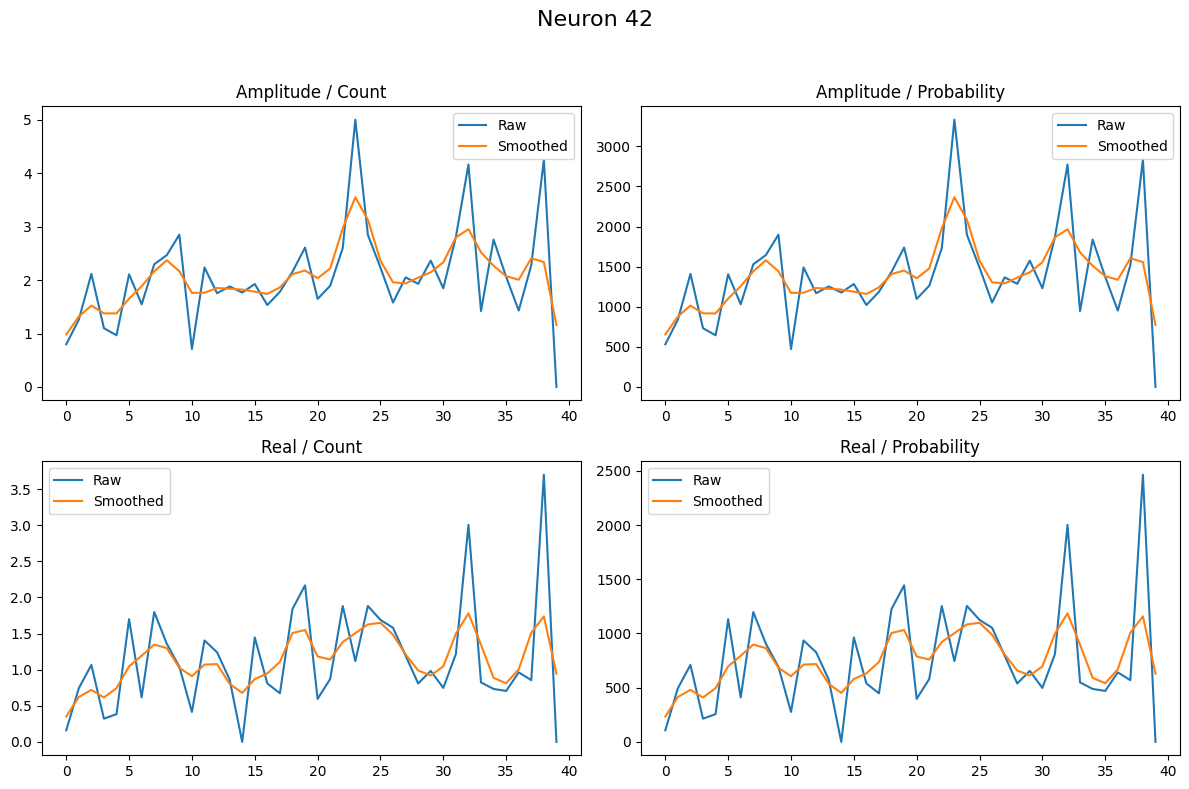

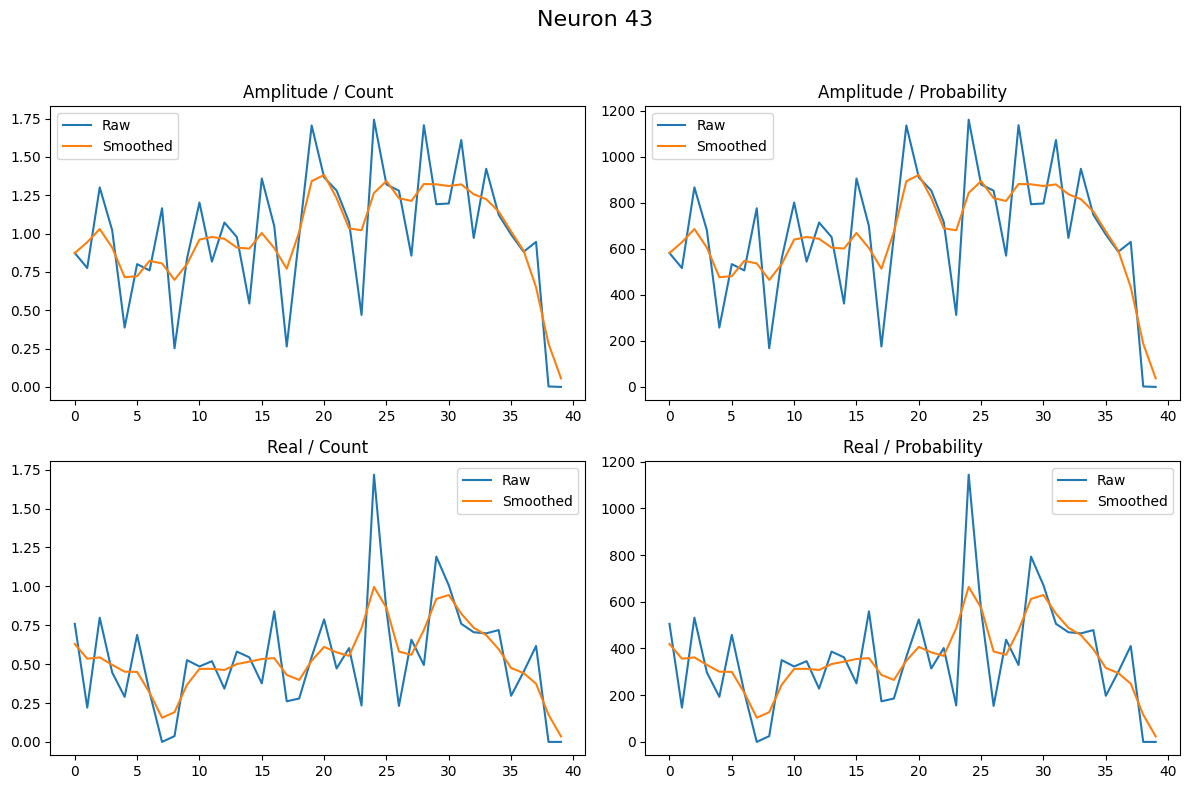

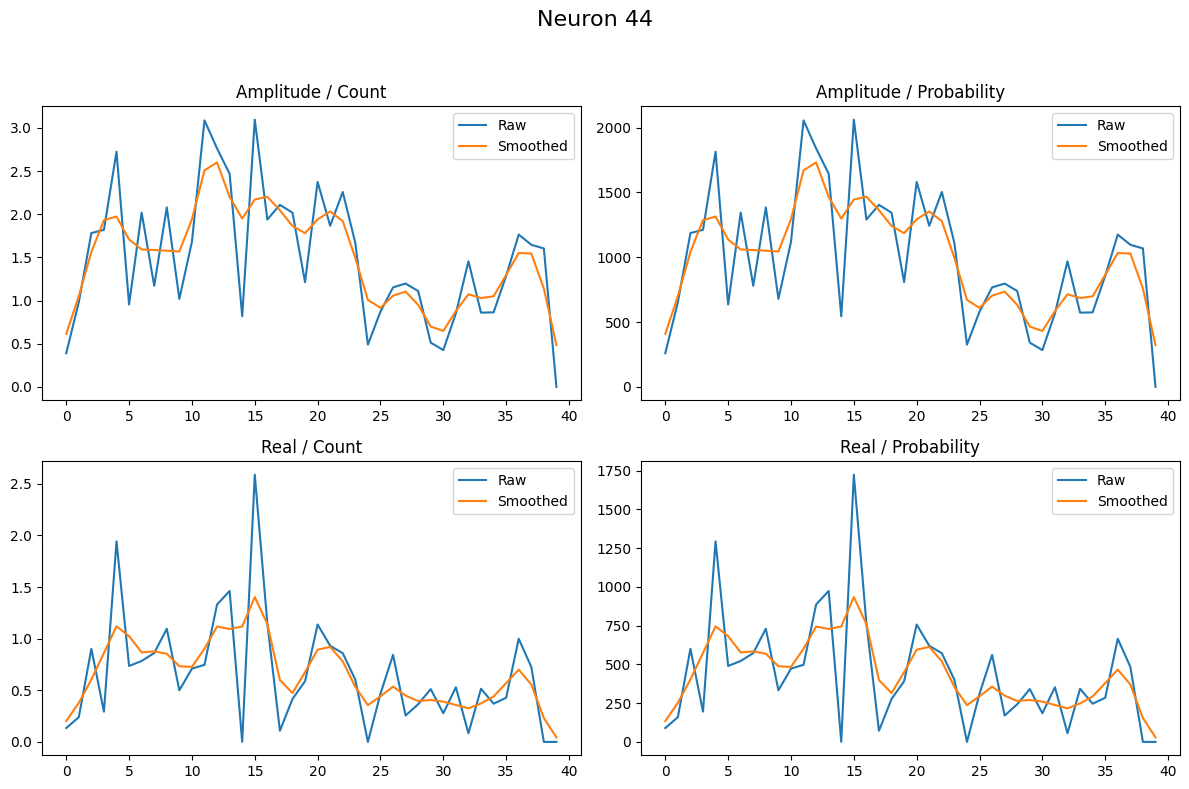

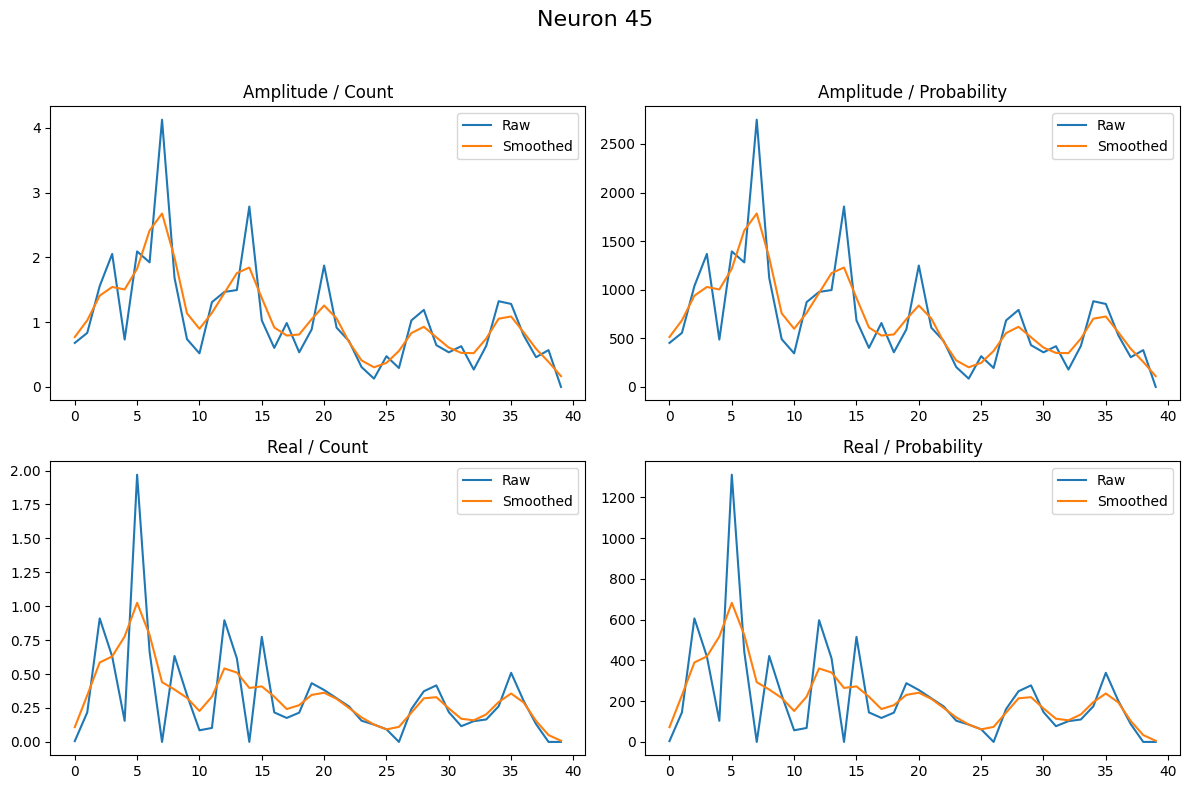

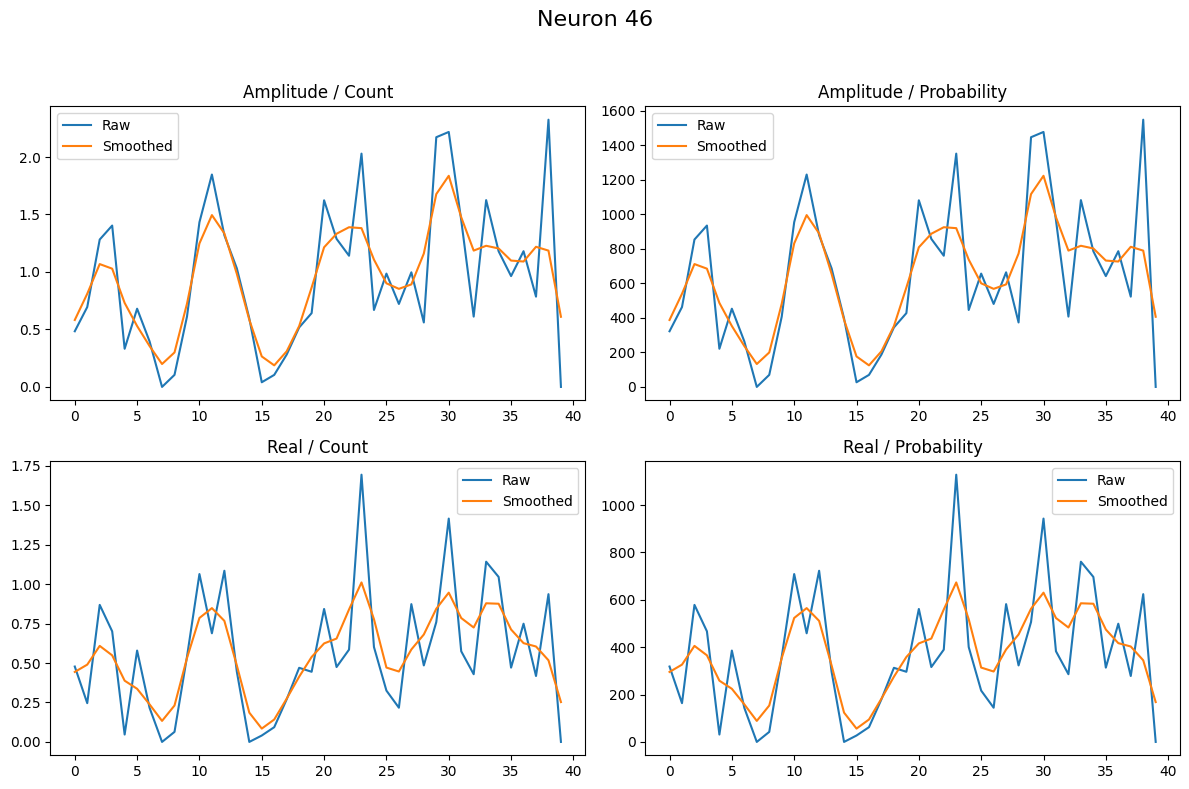

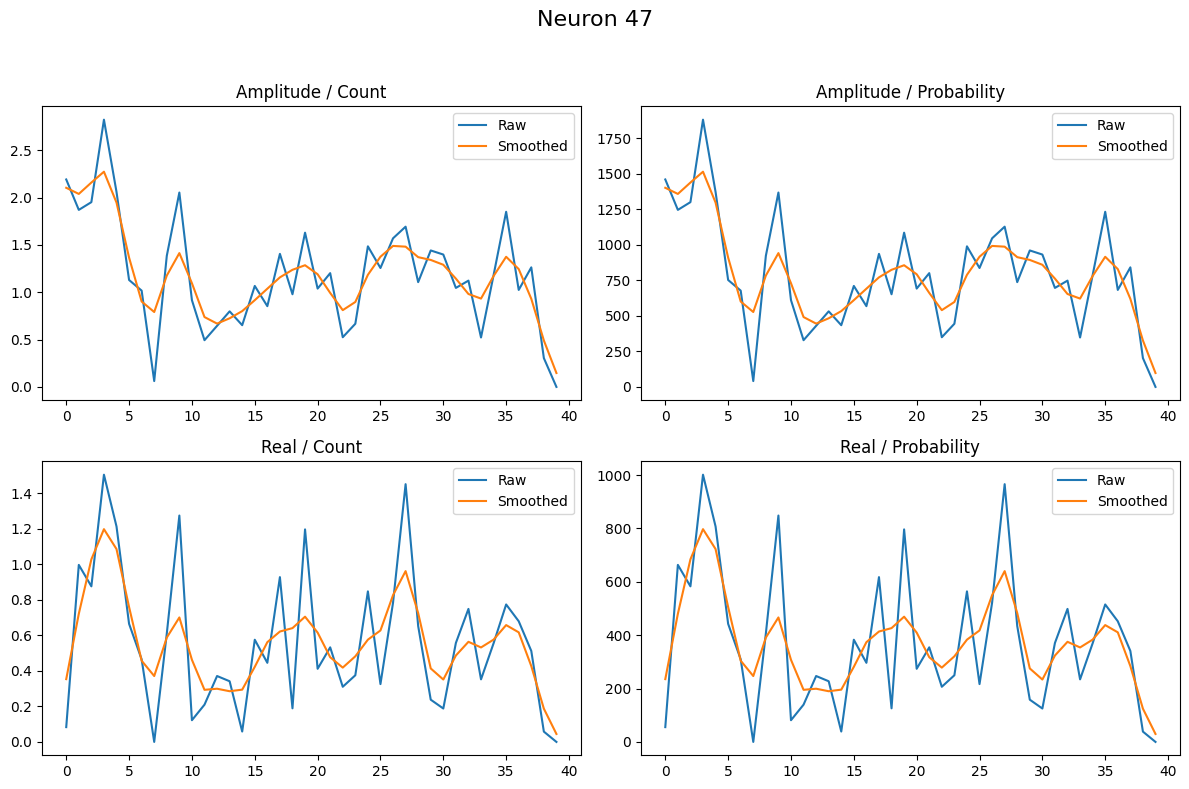

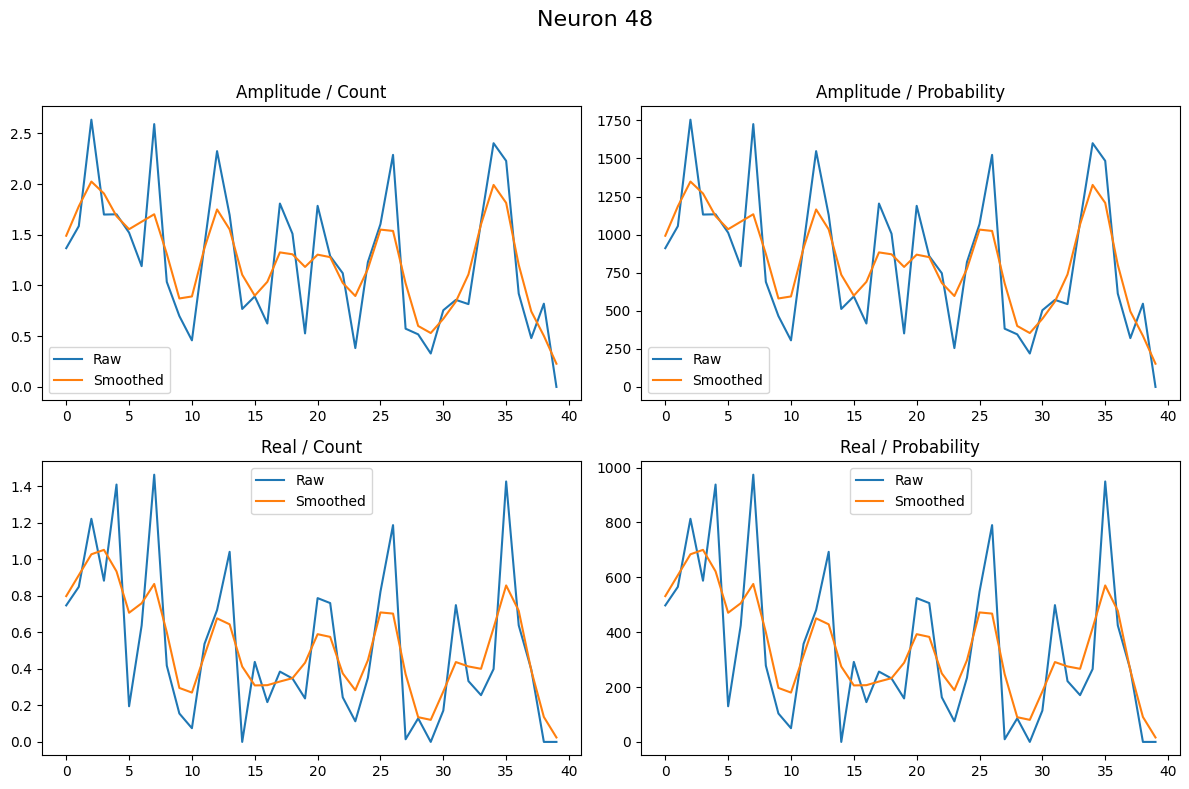

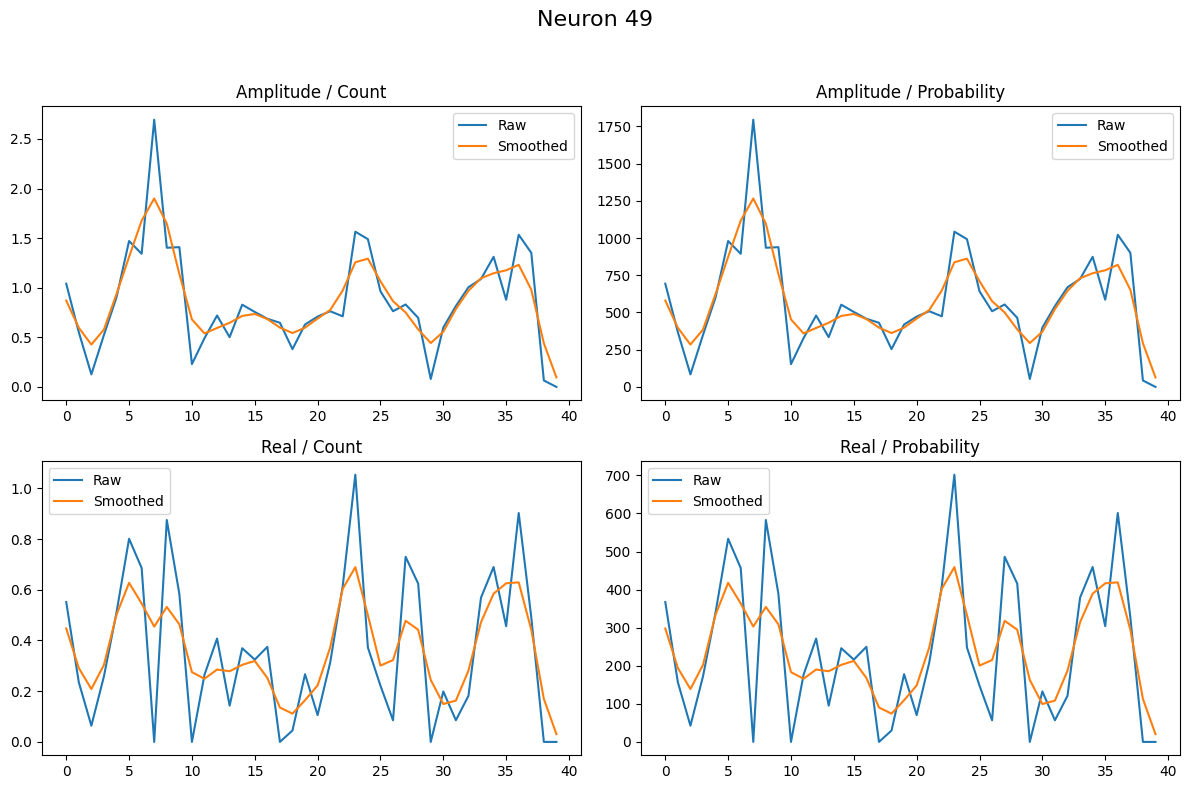

In [19]:
for result in all_results:

    neuron = result["neuron"]

    fig, ax = plt.subplots(2, 2, figsize=(12, 8))

    maps = [
        ("Amplitude / Count", result["amp_count_rate"], result["amp_count_smoothed"]),
        ("Amplitude / Probability", result["amp_prob_rate"], result["amp_prob_smoothed"]),
        ("Real / Count", result["real_count_rate"], result["real_count_smoothed"]),
        ("Real / Probability", result["real_prob_rate"], result["real_prob_smoothed"]),
    ]

    for axis, (title, raw, smooth) in zip(ax.ravel(), maps):
        axis.plot(raw, label="Raw")
        axis.plot(smooth, label="Smoothed")
        axis.set_title(title)
        axis.legend()

    fig.suptitle(f"Neuron {neuron}", fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    